# **Task 1**

**ARCH(4)**


ARCH(4) Estimation Results for N = 10000
                        Zero Mean - ARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -19889.2
Distribution:                  Normal   AIC:                           39788.3
Method:            Maximum Likelihood   BIC:                           39824.4
                                        No. Observations:                10000
Date:                Wed, Feb 18 2026   Df Residuals:                    10000
Time:                        22:24:32   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          1.0319 

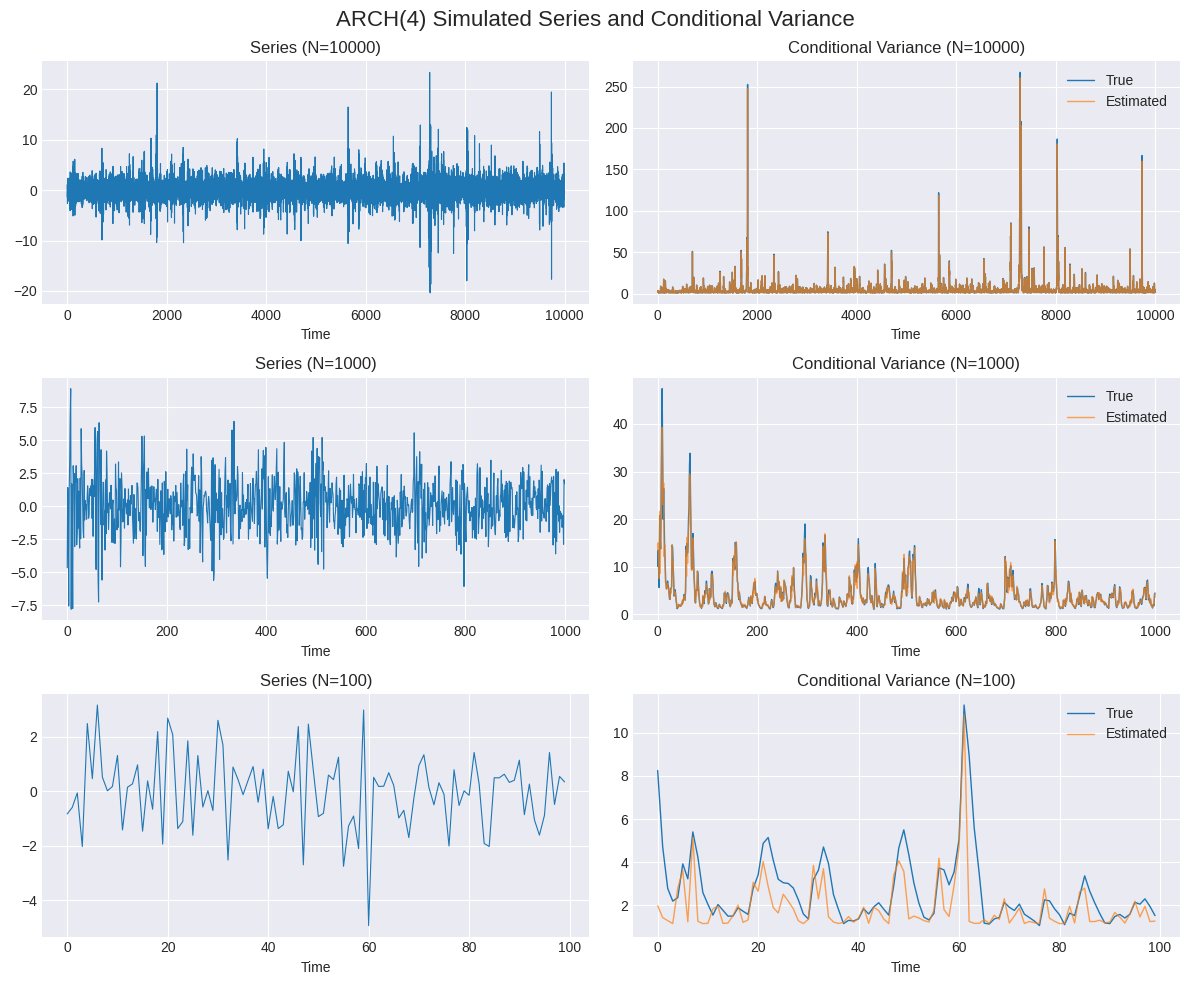


ARCH(4) Estimation Results Comparison Across Sample Sizes
Parameter       True       N=10000      N=1000       N=100       
--------------------------------------------------------------------------------
omega           1.000      1.032 (0.041)  1.136 (0.132)  1.157 (0.394)  
alpha[1]   0.300      0.298 (0.017)  0.308 (0.057)  0.398 (0.159)  
alpha[2]   0.250      0.239 (0.015)  0.117 (0.035)  0.000 (0.103)  
alpha[3]   0.150      0.130 (0.014)  0.184 (0.041)  0.000 (0.085)  
alpha[4]   0.100      0.112 (0.014)  0.115 (0.039)  0.000 (0.217)  
sum(alpha)      0.800      0.779 (---)  0.723 (---)  0.398 (---)  
uncond var      5.000      4.675 (---)  4.107 (---)  1.922 (---)  
sample mean     0.000      0.031 (---)  0.108 (---)  -0.015 (---)  
sample var      5.000      4.919 (---)  3.946 (---)  1.905 (---)  
sample skew     0.000      -0.013 (---)  -0.054 (---)  -0.245 (---)  


In [ ]:
"""
ARCH(4) model simulation and estimation for three sample sizes.
True model: ε_t = σ_t * z_t, z_t ~ N(0,1)
σ_t^2 = 1 + 0.3 ε_{t-1}^2 + 0.25 ε_{t-2}^2 + 0.15 ε_{t-3}^2 + 0.1 ε_{t-4}^2
Unconditional variance = 1 / (1 - 0.8) = 5
Mean = 0, skewness = 0
"""

import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import skew

# True parameters
omega_true = 1.0
alphas_true = [0.3, 0.25, 0.15, 0.1]
sum_alpha_true = sum(alphas_true)
uncond_var_true = omega_true / (1 - sum_alpha_true)  # 5.0
mean_true = 0.0
skew_true = 0.0

def generate_arch4(n, omega, alphas, burn=1000):
    """Generate ARCH(4) series with burn-in."""
    p = len(alphas)
    total = n + burn
    eps = np.zeros(total)
    sigma2 = np.zeros(total)
    z = np.random.normal(size=total)
    for t in range(p, total):
        sigma2[t] = omega + np.sum(alphas * eps[t-p:t][::-1]**2)
        eps[t] = np.sqrt(sigma2[t]) * z[t]
    return eps[-n:], sigma2[-n:]

# Lengths to test
lengths = [10000, 1000, 100]
results_arch = {}

# Create figure for all three sample sizes
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('ARCH(4) Simulated Series and Conditional Variance', fontsize=16)

for idx, N in enumerate(lengths):
    np.random.seed(123 + idx)  # different seed for each length
    eps, sigma2_true = generate_arch4(N, omega_true, alphas_true)

    # Fit ARCH(4) with zero mean
    model = arch_model(eps, mean='zero', vol='ARCH', p=4)
    res = model.fit(disp='off')

    # Print full summary
    print(f"\n{'='*60}")
    print(f"ARCH(4) Estimation Results for N = {N}")
    print(f"{'='*60}")
    print(res.summary().as_text())
    print()

    # Extract estimates and standard errors
    omega_est = res.params['omega']
    omega_se = res.std_err['omega']
    alpha_ests = [res.params[f'alpha[{i}]'] for i in range(1,5)]
    alpha_ses = [res.std_err[f'alpha[{i}]'] for i in range(1,5)]
    sum_alpha_est = sum(alpha_ests)
    # Unconditional variance estimate (if sum(alpha) < 1)
    if sum_alpha_est < 1:
        uncond_var_est = omega_est / (1 - sum_alpha_est)
    else:
        uncond_var_est = np.nan

    # Sample moments
    sample_mean = np.mean(eps)
    sample_var = np.var(eps)
    sample_skew = skew(eps)

    # Store results
    results_arch[N] = {
        'omega_est': omega_est, 'omega_se': omega_se,
        'alpha_ests': alpha_ests, 'alpha_ses': alpha_ses,
        'sum_alpha_est': sum_alpha_est,
        'uncond_var_est': uncond_var_est,
        'sample_mean': sample_mean,
        'sample_var': sample_var,
        'sample_skew': sample_skew,
        'res': res,
        'sigma2_true': sigma2_true,
        'eps': eps
    }

    # Plot in the corresponding row
    ax_left = axes[idx, 0]
    ax_right = axes[idx, 1]

    ax_left.plot(eps, lw=0.8)
    ax_left.set_title(f'Series (N={N})')
    ax_left.set_xlabel('Time')

    cond_vol_est = res.conditional_volatility
    ax_right.plot(sigma2_true, label='True', lw=1)
    ax_right.plot(cond_vol_est**2, label='Estimated', lw=1, alpha=0.7)
    ax_right.set_title(f'Conditional Variance (N={N})')
    ax_right.set_xlabel('Time')
    ax_right.legend()

plt.tight_layout()
plt.show()

# Print comparison table
print("\n" + "="*80)
print("ARCH(4) Estimation Results Comparison Across Sample Sizes")
print("="*80)
header = f"{'Parameter':<15} {'True':<10} " + " ".join([f"N={N:<10}" for N in lengths])
print(header)
print("-"*80)

# omega
row = f"{'omega':<15} {omega_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['omega_est']:.3f} ({r['omega_se']:.3f})  "
print(row)

# alphas
for i in range(4):
    row = f"alpha[{i+1}]   {alphas_true[i]:<10.3f} "
    for N in lengths:
        r = results_arch[N]
        row += f"{r['alpha_ests'][i]:.3f} ({r['alpha_ses'][i]:.3f})  "
    print(row)

# sum of alphas
row = f"{'sum(alpha)':<15} {sum_alpha_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['sum_alpha_est']:.3f} (---)  "
print(row)

# unconditional variance
row = f"{'uncond var':<15} {uncond_var_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    val = r['uncond_var_est']
    row += f"{val:.3f} (---)  " if not np.isnan(val) else " nan (---)  "
print(row)

# sample mean
row = f"{'sample mean':<15} {mean_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['sample_mean']:.3f} (---)  "
print(row)

# sample variance
row = f"{'sample var':<15} {uncond_var_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['sample_var']:.3f} (---)  "
print(row)

# sample skew
row = f"{'sample skew':<15} {skew_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['sample_skew']:.3f} (---)  "
print(row)

**GARCH(1,1)**


GARCH(1,1) Estimation Results for N = 10000
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13702.4
Distribution:                  Normal   AIC:                           27410.9
Method:            Maximum Likelihood   BIC:                           27432.5
                                        No. Observations:                10000
Date:                Wed, Feb 18 2026   Df Residuals:                    10000
Time:                        22:24:33   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.11

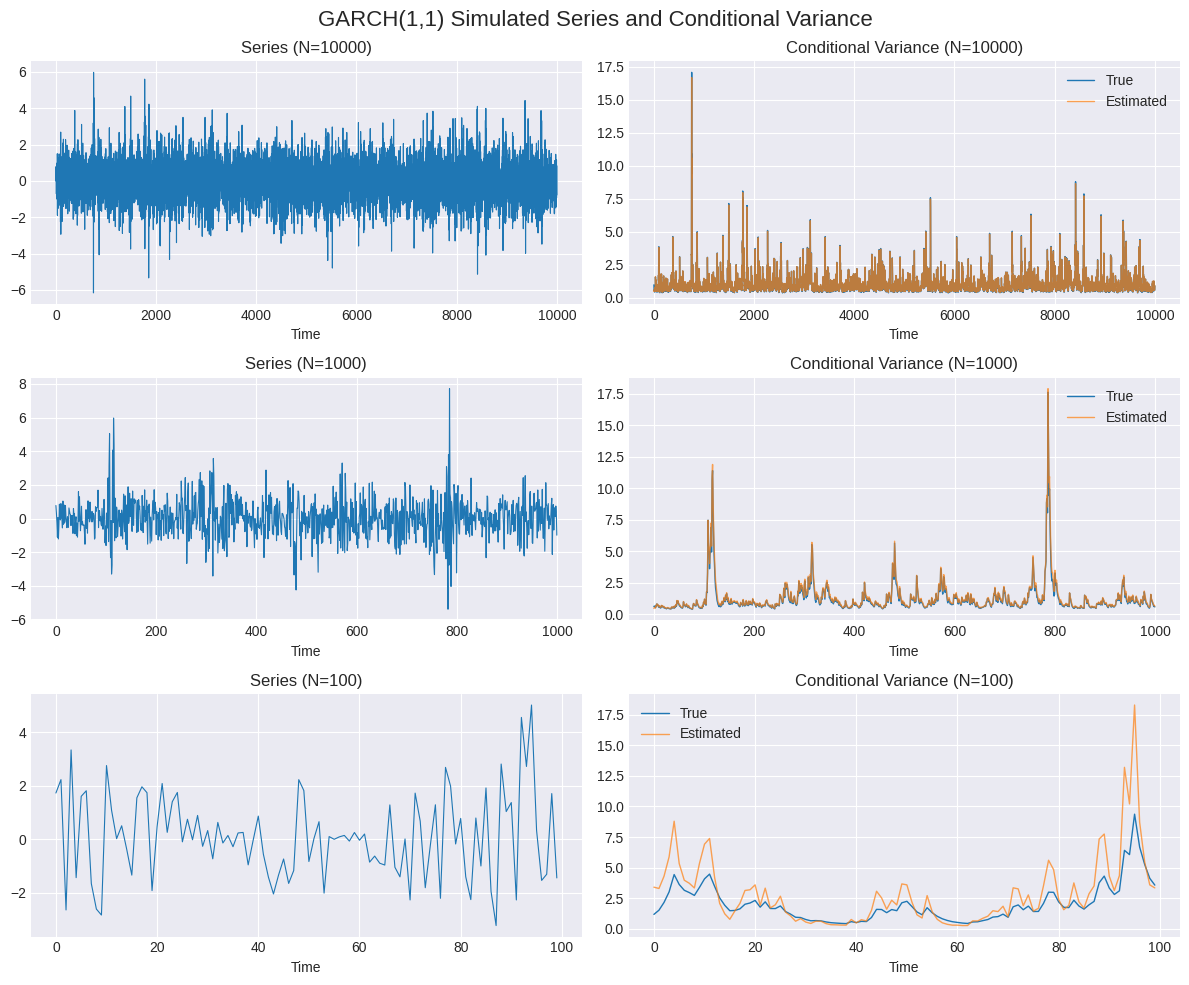


GARCH(1,1) Estimation Results Comparison Across Sample Sizes
Parameter       True       N=10000      N=1000       N=100       
--------------------------------------------------------------------------------
omega           0.100      0.114 (0.010)  0.092 (0.025)  0.121 (0.078)  
alpha           0.200      0.197 (0.011)  0.194 (0.030)  0.534 (0.149)  
beta            0.700      0.694 (0.017)  0.735 (0.035)  0.466 (0.120)  
persistence     0.900      0.891 (---)  0.929 (---)  1.000 (---)  
uncond var      1.000      1.045 (---)  1.296 (---)   nan (---)  
sample mean     0.000      -0.007 (---)  0.020 (---)  0.099 (---)  
sample var      1.000      1.042 (---)  1.328 (---)  2.581 (---)  
sample skew     0.000      0.020 (---)  0.383 (---)  0.378 (---)  


In [ ]:
"""
GARCH(1,1) model simulation and estimation for three sample sizes.
True model: ε_t = σ_t * z_t, z_t ~ N(0,1)
σ_t^2 = 0.1 + 0.2 ε_{t-1}^2 + 0.7 σ_{t-1}^2
Unconditional variance = 0.1 / (1 - 0.9) = 1
Mean = 0, skewness = 0
"""

import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import skew

# True parameters
omega_true = 0.1
alpha_true = 0.2
beta_true = 0.7
persistence = alpha_true + beta_true   # 0.9
uncond_var_true = omega_true / (1 - persistence)  # 1.0
mean_true = 0.0
skew_true = 0.0

def generate_garch11(n, omega, alpha, beta, burn=1000):
    """Generate GARCH(1,1) series with burn-in."""
    total = n + burn
    eps = np.zeros(total)
    sigma2 = np.zeros(total)
    z = np.random.normal(size=total)
    # Initialize at unconditional variance
    sigma2[0] = omega / (1 - alpha - beta)
    eps[0] = np.sqrt(sigma2[0]) * z[0]
    for t in range(1, total):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        eps[t] = np.sqrt(sigma2[t]) * z[t]
    return eps[-n:], sigma2[-n:]

# Lengths to test
lengths = [10000, 1000, 100]
results_garch = {}

# Create figure for all three sample sizes
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('GARCH(1,1) Simulated Series and Conditional Variance', fontsize=16)

for idx, N in enumerate(lengths):
    np.random.seed(456 + idx)  # different seed for each length
    eps, sigma2_true = generate_garch11(N, omega_true, alpha_true, beta_true)

    # Fit GARCH(1,1) with zero mean
    model = arch_model(eps, mean='zero', vol='GARCH', p=1, q=1)
    res = model.fit(disp='off')

    # Print full summary
    print(f"\n{'='*60}")
    print(f"GARCH(1,1) Estimation Results for N = {N}")
    print(f"{'='*60}")
    print(res.summary().as_text())
    print()

    # Extract estimates and standard errors
    omega_est = res.params['omega']
    omega_se = res.std_err['omega']
    alpha_est = res.params['alpha[1]']
    alpha_se = res.std_err['alpha[1]']
    beta_est = res.params['beta[1]']
    beta_se = res.std_err['beta[1]']
    persist_est = alpha_est + beta_est
    # Unconditional variance estimate (if persist < 1)
    if persist_est < 1:
        uncond_var_est = omega_est / (1 - persist_est)
    else:
        uncond_var_est = np.nan

    # Sample moments
    sample_mean = np.mean(eps)
    sample_var = np.var(eps)
    sample_skew = skew(eps)

    # Store results
    results_garch[N] = {
        'omega_est': omega_est, 'omega_se': omega_se,
        'alpha_est': alpha_est, 'alpha_se': alpha_se,
        'beta_est': beta_est, 'beta_se': beta_se,
        'persist_est': persist_est,
        'uncond_var_est': uncond_var_est,
        'sample_mean': sample_mean,
        'sample_var': sample_var,
        'sample_skew': sample_skew,
        'res': res,
        'sigma2_true': sigma2_true,
        'eps': eps
    }

    # Plot in the corresponding row
    ax_left = axes[idx, 0]
    ax_right = axes[idx, 1]

    ax_left.plot(eps, lw=0.8)
    ax_left.set_title(f'Series (N={N})')
    ax_left.set_xlabel('Time')

    cond_vol_est = res.conditional_volatility
    ax_right.plot(sigma2_true, label='True', lw=1)
    ax_right.plot(cond_vol_est**2, label='Estimated', lw=1, alpha=0.7)
    ax_right.set_title(f'Conditional Variance (N={N})')
    ax_right.set_xlabel('Time')
    ax_right.legend()

plt.tight_layout()
plt.show()

# Print comparison table
print("\n" + "="*80)
print("GARCH(1,1) Estimation Results Comparison Across Sample Sizes")
print("="*80)
header = f"{'Parameter':<15} {'True':<10} " + " ".join([f"N={N:<10}" for N in lengths])
print(header)
print("-"*80)

# omega
row = f"{'omega':<15} {omega_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['omega_est']:.3f} ({r['omega_se']:.3f})  "
print(row)

# alpha
row = f"{'alpha':<15} {alpha_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['alpha_est']:.3f} ({r['alpha_se']:.3f})  "
print(row)

# beta
row = f"{'beta':<15} {beta_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['beta_est']:.3f} ({r['beta_se']:.3f})  "
print(row)

# persistence
row = f"{'persistence':<15} {persistence:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['persist_est']:.3f} (---)  "
print(row)

# unconditional variance
row = f"{'uncond var':<15} {uncond_var_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    val = r['uncond_var_est']
    row += f"{val:.3f} (---)  " if not np.isnan(val) else " nan (---)  "
print(row)

# sample mean
row = f"{'sample mean':<15} {mean_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['sample_mean']:.3f} (---)  "
print(row)

# sample variance
row = f"{'sample var':<15} {uncond_var_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['sample_var']:.3f} (---)  "
print(row)

# sample skew
row = f"{'sample skew':<15} {skew_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['sample_skew']:.3f} (---)  "
print(row)

# **Task 5**

In [ ]:
!pip install arch pmdarima

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss, pacf, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Russtockdaily.csv', parse_dates=True, index_col=0)
price = df['MOEX'].dropna()
log_returns = np.log(price / price.shift(1)).dropna()
print(f"Data range: {log_returns.index[0]} to {log_returns.index[-1]}")
print(f"Number of observations: {len(log_returns)}")

Data range: 3516 to 4441
Number of observations: 926


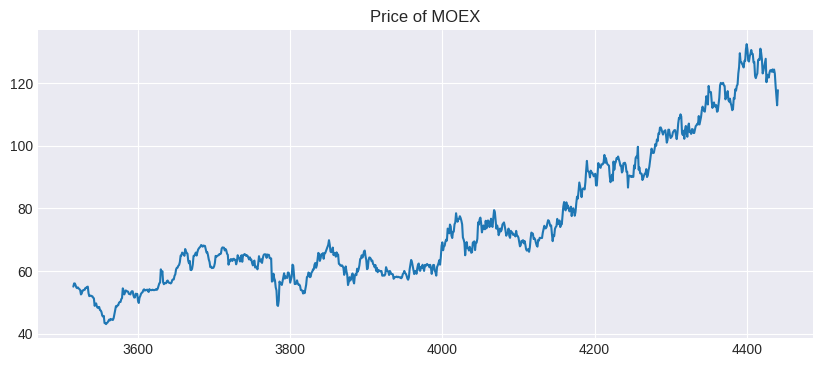

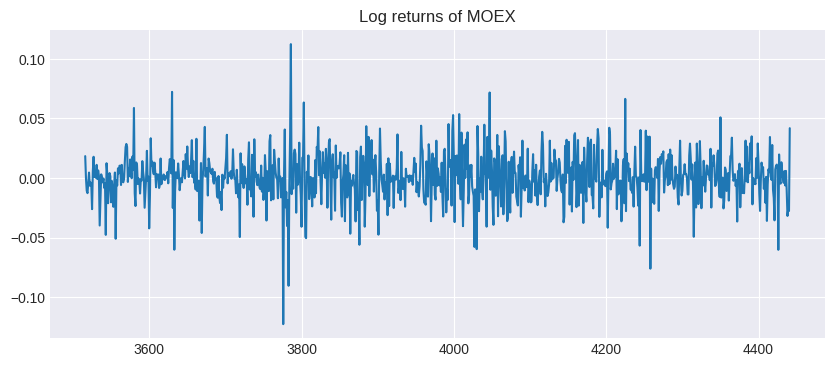

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(price)
plt.title('Price of MOEX')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(log_returns)
plt.title('Log returns of MOEX')
plt.show()

In [ ]:
def run_stationarity_tests(series, name):
    print(f"\n{'='*60}")
    print(f"STATIONARITY ANALYSIS: {name}")
    print(f"{'='*60}")

    # ADF Test with automatic lag selection (AIC)
    print("\n1. AUGMENTED DICKEY-FULLER (ADF) TEST:")
    adf_result = adfuller(series, autolag='AIC')
    print(f"   Test Statistic: {adf_result[0]:.4f}")
    print(f"   p-value: {adf_result[1]:.4f}")
    print(f"   Lags used: {adf_result[2]}")
    print(f"   Critical Values:")
    for key, val in adf_result[4].items():
        print(f"     {key}: {val:.4f}")

    # KPSS Test
    print("\n2. KPSS TEST:")
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f"   Test Statistic: {kpss_result[0]:.4f}")
    print(f"   p-value: {kpss_result[1]:.4f}")

    # PP Test
    print("\n3. PHILLIPS-PERRON (PP) TEST:")
    pp_result = adfuller(series, autolag=None, maxlag=0)
    print(f"   Test Statistic: {pp_result[0]:.4f}")
    print(f"   p-value: {pp_result[1]:.4f}")

    # Determine stationarity
    adf_stationary = adf_result[1] <= 0.05
    kpss_stationary = kpss_result[1] >= 0.05

    print(f"\nCONCLUSION: ", end="")
    if adf_stationary and kpss_stationary:
        print("SERIES IS STATIONARY (both tests agree)")
    elif not adf_stationary and not kpss_stationary:
        print("SERIES IS NON-STATIONARY (both tests agree)")
    else:
        print("MIXED RESULTS - further investigation needed")

    return {
        'adf': adf_result,
        'kpss': kpss_result,
        'pp': pp_result,
        'is_stationary_adf': adf_stationary,
        'is_stationary_kpss': kpss_stationary
    }

run_stationarity_tests(price, 'MOEX price')
run_stationarity_tests(log_returns, 'MOEX returns')


STATIONARITY ANALYSIS: MOEX price

1. AUGMENTED DICKEY-FULLER (ADF) TEST:
   Test Statistic: -0.3612
   p-value: 0.9164
   Lags used: 0
   Critical Values:
     1%: -3.4374
     5%: -2.8647
     10%: -2.5684

2. KPSS TEST:
   Test Statistic: 4.0648
   p-value: 0.0100

3. PHILLIPS-PERRON (PP) TEST:
   Test Statistic: -0.3612
   p-value: 0.9164

CONCLUSION: SERIES IS NON-STATIONARY (both tests agree)

STATIONARITY ANALYSIS: MOEX returns

1. AUGMENTED DICKEY-FULLER (ADF) TEST:
   Test Statistic: -19.2034
   p-value: 0.0000
   Lags used: 2
   Critical Values:
     1%: -3.4375
     5%: -2.8647
     10%: -2.5684

2. KPSS TEST:
   Test Statistic: 0.0767
   p-value: 0.1000

3. PHILLIPS-PERRON (PP) TEST:
   Test Statistic: -29.9488
   p-value: 0.0000

CONCLUSION: SERIES IS STATIONARY (both tests agree)


{'adf': (np.float64(-19.20341451015971),
  0.0,
  2,
  923,
  {'1%': np.float64(-3.437454636606558),
   '5%': np.float64(-2.8646764401027336),
   '10%': np.float64(-2.5684400361180333)},
  np.float64(-4491.193105120619)),
 'kpss': (np.float64(0.07665820507061222),
  np.float64(0.1),
  12,
  {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}),
 'pp': (np.float64(-29.948793056322593),
  0.0,
  0,
  925,
  {'1%': np.float64(-3.437439232284603),
   '5%': np.float64(-2.8646696476686477),
   '10%': np.float64(-2.5684364181154127)}),
 'is_stationary_adf': True,
 'is_stationary_kpss': np.True_}

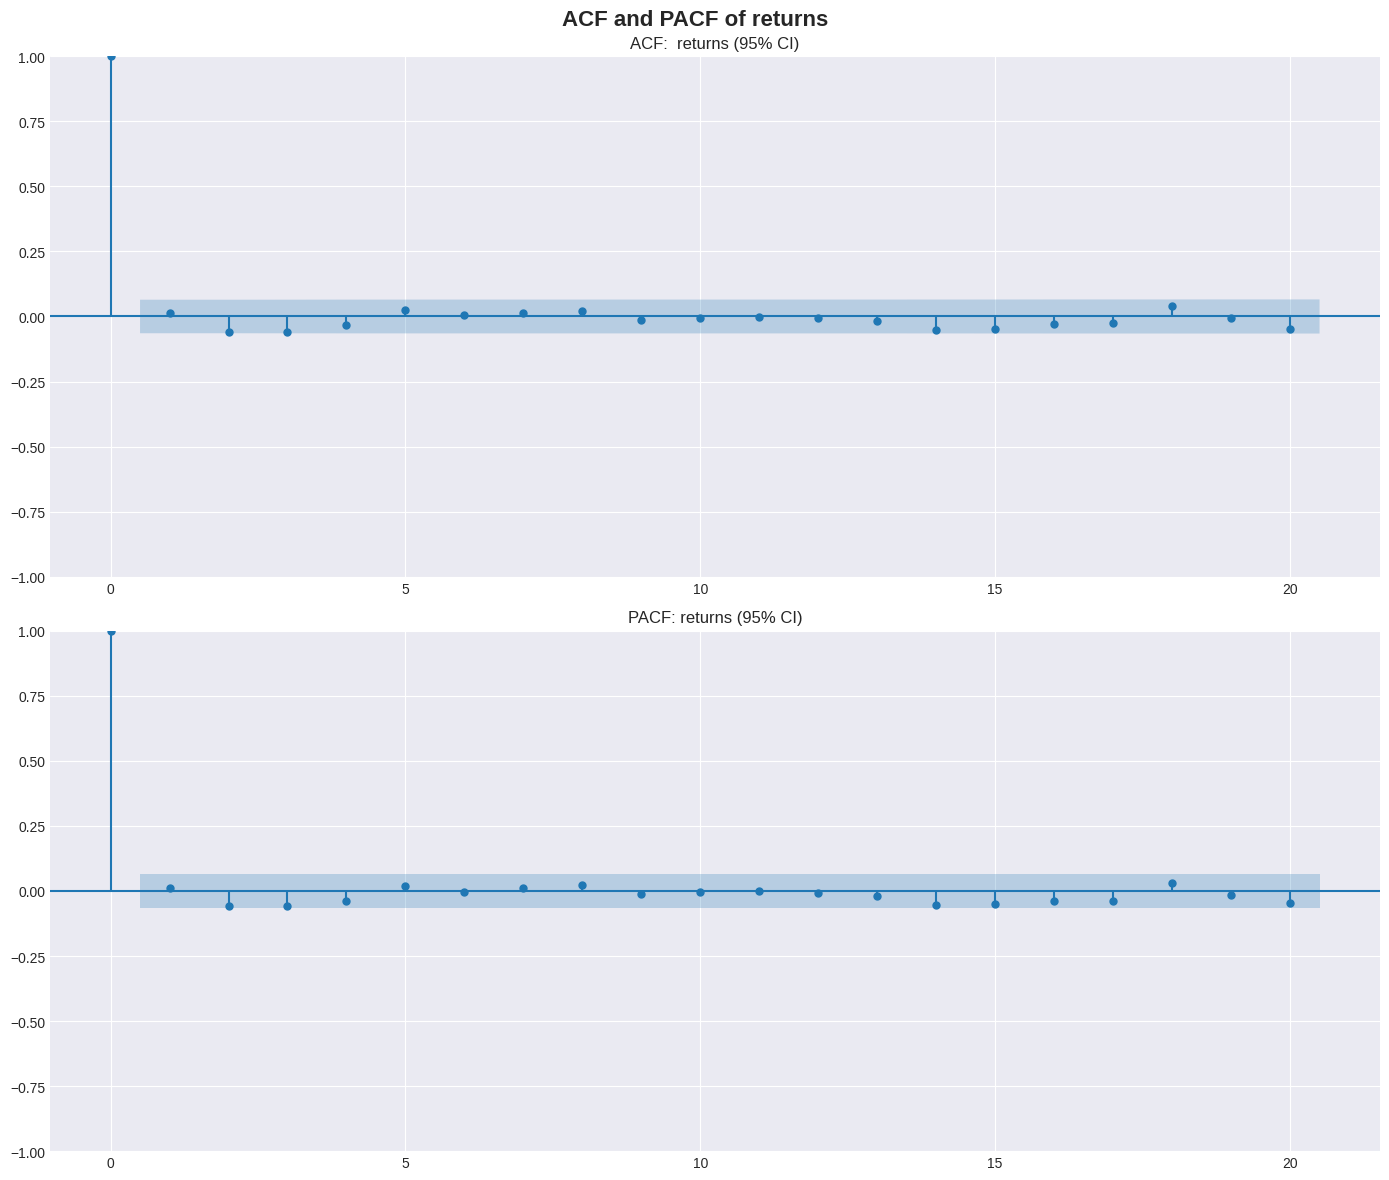

In [ ]:
fig, axes = plt.subplots(2, 1, figsize = (14, 12))
fig.suptitle('ACF and PACF of returns', fontsize=16, fontweight='bold')
plot_acf(log_returns, lags=20, ax=axes[0], alpha=0.05, title=f'ACF:  returns (95% CI)')
plot_pacf(log_returns, lags=20, ax=axes[1], alpha=0.05, title=f'PACF: returns (95% CI)')

plt.tight_layout()
plt.show()

In [ ]:
base_model = pm.auto_arima(log_returns, seasonal=False)
base_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  926
Model:                        SARIMAX   Log Likelihood                2306.533
Date:                Wed, 18 Feb 2026   AIC                          -4611.066
Time:                        22:24:47   BIC                          -4606.235
Sample:                             0   HQIC                         -4609.223
                                - 926                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0004   1.13e-05     35.400      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):               468.13
Prob(Q):                              0.71   Prob(JB):                         0.00
Heteroskedasticity (H):               0.87   Skew:                            -0.21
Prob(H) (two-sided):                  0.20   Kurtosis:                         6.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
base_model

ARIMA(order=(0, 0, 0), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

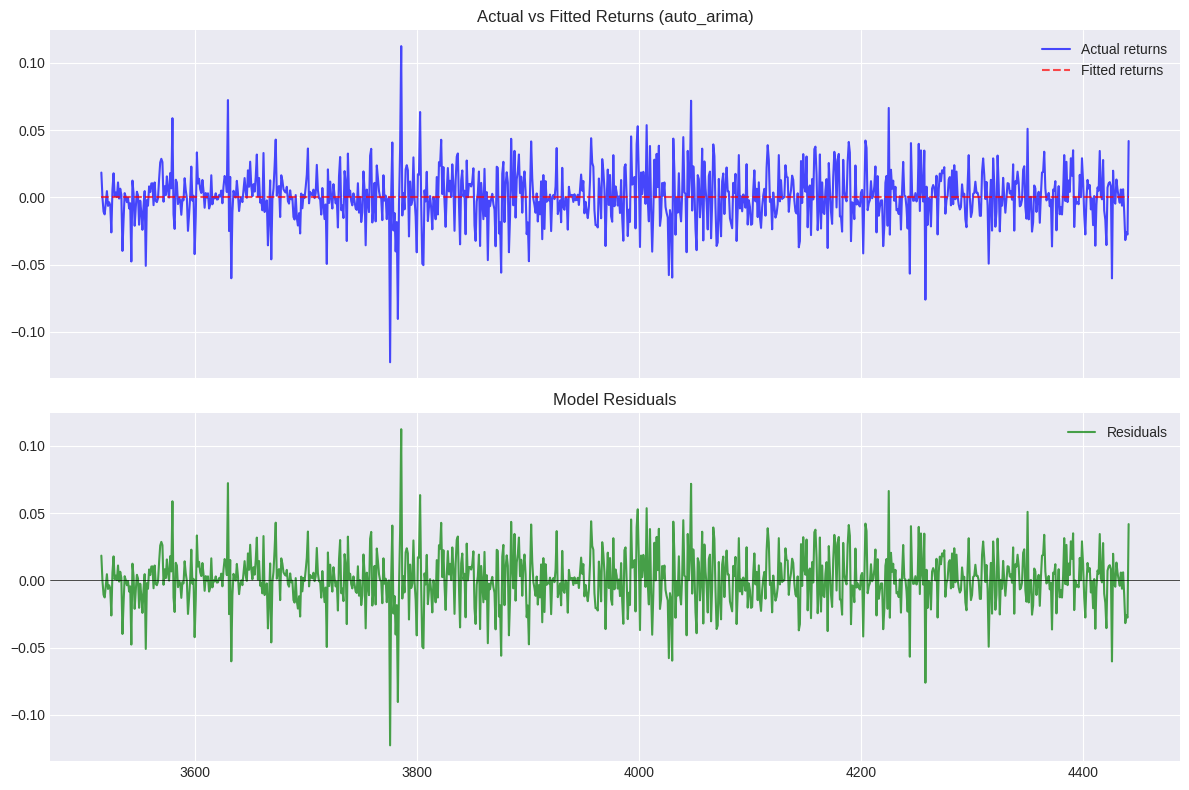

In [ ]:

# Get fitted values and residuals from the auto_arima model
fitted = base_model.fittedvalues()
residuals = base_model.resid()

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top subplot: actual vs fitted returns
axes[0].plot(log_returns.index, log_returns, label='Actual returns', color='blue', alpha=0.7)
axes[0].plot(log_returns.index, fitted, label='Fitted returns', color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Actual vs Fitted Returns (auto_arima)')
axes[0].legend()
axes[0].grid(True)

# Bottom subplot: residuals
axes[1].plot(log_returns.index, residuals, label='Residuals', color='green', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Model Residuals')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:

models = {
    # Standard GARCH
    'GARCH(1,1)':       {'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 1},
    'GARCH(2,1)':       {'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 1},
    'GARCH(1,2)':       {'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 2},
    'GARCH(2,2)':       {'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 2},
    'GARCH(1,3)':       {'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 3},
    'GARCH(3,1)':       {'vol': 'GARCH', 'p': 3, 'o': 0, 'q': 1},
    'GARCH(3,3)':       {'vol': 'GARCH', 'p': 3, 'o': 0, 'q': 3},

    # Asymmetric / leverage models
    'EGARCH(1,1)':      {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1},
    'EGARCH(1,2)':      {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 2},
    'EGARCH(2,1)':      {'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 1},
    'GJR-GARCH(1,1)':   {'vol': 'GARCH',   'p': 1, 'o': 1, 'q': 1},   # same as TGARCH
    'GJR-GARCH(2,1)':   {'vol': 'GARCH',   'p': 2, 'o': 1, 'q': 1},
    'GJR-GARCH(1,2)':   {'vol': 'GARCH',   'p': 1, 'o': 1, 'q': 2},

    # Advanced specifications
    'FIGARCH(1,1)':     {'vol': 'FIGARCH', 'p': 1, 'q': 1},            # d is estimated
    'APARCH(1,1)':      {'vol': 'APARCH',  'p': 1, 'o': 1, 'q': 1},    # power estimated
    # Power ARCH (symmetric) – use APARCH with o=0
    'PowerGARCH(1,1)':  {'vol': 'APARCH',  'p': 1, 'o': 0, 'q': 1},
}

# ----------------------------------------------------------------------
# 3. Define AR orders to iterate over
# ----------------------------------------------------------------------
ar_orders = [0, 1, 2]

# ----------------------------------------------------------------------
# 4. Fit each model with AR(0), AR(1), AR(2) mean and collect results
# ----------------------------------------------------------------------
results = []

for name, spec in models.items():
    for ar in ar_orders:
        # Construct model name with AR order
        model_name = f"AR({ar})-{name}"

        # Initialize result dictionary
        res = {
            'Model': model_name,
            'Params': np.nan,
            'AIC': np.nan,
            'BIC': np.nan,
            'LogLik': np.nan,
            'LB_resid_p': np.nan,
            'LB_sq_p': np.nan,
            'Converged': False,
            'Error': ''
        }

        try:
            # Choose mean specification based on AR order
            if ar == 0:
                mean_spec = 'Constant'
                lags = None  # not used for Constant mean
            else:
                mean_spec = 'AR'
                lags = ar

            # Set up the model
            model = arch_model(
                log_returns,
                mean=mean_spec,
                lags=lags,                # only used when mean='AR'
                vol=spec['vol'],
                p=spec['p'],
                o=spec.get('o', 0),       # asymmetry order (default 0 if not given)
                q=spec['q'],
                dist='ged'                 # generalized error distribution
            )

            # Fit the model
            fitted = model.fit(disp='off', show_warning=False)

            # Extract diagnostics
            resid = fitted.resid
            sq_resid = resid**2

            # Ljung-Box test on residuals and squared residuals at lag 10
            lb_resid = acorr_ljungbox(resid, lags=[10], return_df=True).iloc[0, 1]
            lb_sq = acorr_ljungbox(sq_resid, lags=[10], return_df=True).iloc[0, 1]

            # Update result dictionary
            res.update({
                'Params': len(fitted.params),
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'LogLik': fitted.loglikelihood,
                'LB_resid_p': lb_resid,
                'LB_sq_p': lb_sq,
                'Converged': fitted.convergence_flag == 0,
                'Error': '' if fitted.convergence_flag == 0 else f"Convergence flag = {fitted.convergence_flag}"
            })

        except Exception as e:
            # If model fails completely, record the error
            res['Error'] = str(e)[:100]

        results.append(res)

# ----------------------------------------------------------------------
# 5. Create DataFrame and display results
# ----------------------------------------------------------------------
df = pd.DataFrame(results)

# Separate successful (converged and no error) from problematic
df_success = df[df['Converged'] == True].copy()
df_failed  = df[df['Converged'] == False].copy()

# Sort successful models by AIC (lower is better)
df_success = df_success.sort_values('AIC')

# Format numeric columns for readability
for col in ['AIC', 'BIC', 'LogLik']:
    df_success[col] = df_success[col].map('{:.2f}'.format)
df_success['LB_resid_p'] = df_success['LB_resid_p'].map('{:.4f}'.format)
df_success['LB_sq_p']    = df_success['LB_sq_p'].map('{:.4f}'.format)

# Add pass/fail indicators based on p-value > 0.05
df_success['Resid OK']   = df_success['LB_resid_p'].astype(float) > 0.05
df_success['Resid OK']   = df_success['Resid OK'].map({True: '✓', False: '✗'})
df_success['SqResid OK'] = df_success['LB_sq_p'].astype(float) > 0.05
df_success['SqResid OK'] = df_success['SqResid OK'].map({True: '✓', False: '✗'})

# Select columns for final table
display_cols = ['Model', 'Params', 'AIC', 'BIC', 'LogLik',
                'LB_resid_p', 'LB_sq_p', 'Resid OK', 'SqResid OK']

print("\n" + "="*80)
print("GARCH Model Comparison (AR(0), AR(1), AR(2) mean, sorted by AIC)")
print("="*80)
print(df_success[display_cols].to_markdown(index=False, tablefmt="pipe"))

# Show models that did not converge or threw an exception
if not df_failed.empty:
    # Fill any missing error messages
    df_failed['Error'] = df_failed['Error'].fillna("No error message (convergence flag != 0)")
    print("\n" + "-"*80)
    print("Models that did not converge:")
    print(df_failed[['Model', 'Error']].to_markdown(index=False, tablefmt="pipe"))


GARCH Model Comparison (AR(0), AR(1), AR(2) mean, sorted by AIC)
| Model                 |   Params |      AIC |      BIC |   LogLik |   LB_resid_p |   LB_sq_p | Resid OK   | SqResid OK   |
|:----------------------|---------:|---------:|---------:|---------:|-------------:|----------:|:-----------|:-------------|
| AR(0)-EGARCH(1,1)     |        6 | -4731.5  | -4702.51 |  2371.75 |       0.4989 |         0 | ✓          | ✗            |
| AR(0)-EGARCH(2,1)     |        7 | -4729.77 | -4695.95 |  2371.89 |       0.4989 |         0 | ✓          | ✗            |
| AR(0)-FIGARCH(1,1)    |        6 | -4729.75 | -4700.77 |  2370.88 |       0.4989 |         0 | ✓          | ✗            |
| AR(0)-EGARCH(1,2)     |        7 | -4729.73 | -4695.91 |  2371.86 |       0.4989 |         0 | ✓          | ✗            |
| AR(1)-EGARCH(1,1)     |        7 | -4725.52 | -4691.71 |  2369.76 |     nan      |       nan | ✗          | ✗            |
| AR(1)-EGARCH(2,1)     |        8 | -4723.85 | -4685.22 | 

In [ ]:
# Example with one of your selected models
# Re-fit AR(0)-EGARCH(1,1)
model1 = arch_model(log_returns, mean='Constant', vol='EGARCH', p=1, o=1, q=1, dist='t').fit(disp='off')
# Re-fit AR(0)-GARCH(1,1)
model2 = arch_model(log_returns, mean='Constant', vol='GARCH', p=1, o=0, q=1, dist='t').fit(disp='off')

horizon = 5

# For EGARCH (and any model), use simulation method
forecasts1 = model1.forecast(horizon=horizon, method='simulation')
mean_forecast1 = forecasts1.mean.iloc[-1]          # point forecasts of returns
vol_forecast1  = np.sqrt(forecasts1.variance.iloc[-1])  # average simulated variance → std dev

# For GARCH, analytic works, but we can also use simulation (optional)
forecasts2 = model2.forecast(horizon=horizon, method='simulation')
mean_forecast2 = forecasts2.mean.iloc[-1]
vol_forecast2  = np.sqrt(forecasts2.variance.iloc[-1])

print("Model 1 (EGARCH) point forecasts (returns):")
print(mean_forecast1)
print("\nModel 1 volatility forecasts (std dev):")
print(vol_forecast1)

print("\nModel 2 (GARCH) point forecasts (returns):")
print(mean_forecast2)
print("\nModel 2 volatility forecasts (std dev):")
print(vol_forecast2)

Model 1 (EGARCH) point forecasts (returns):
h.1    0.000902
h.2    0.000902
h.3    0.000902
h.4    0.000902
h.5    0.000902
Name: 4441, dtype: float64

Model 1 volatility forecasts (std dev):
h.1    0.021753
h.2    0.021758
h.3    0.021791
h.4    0.021812
h.5    0.021799
Name: 4441, dtype: float64

Model 2 (GARCH) point forecasts (returns):
h.1    0.000935
h.2    0.000935
h.3    0.000935
h.4    0.000935
h.5    0.000935
Name: 4441, dtype: float64

Model 2 volatility forecasts (std dev):
h.1    0.021714
h.2    0.021574
h.3    0.021456
h.4    0.021326
h.5    0.021168
Name: 4441, dtype: float64


In [ ]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - EGARCH Model Results                        
====================================================================================
Dep. Variable:                         MOEX   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:                2367.00
Distribution:      Standardized Student's t   AIC:                          -4722.00
Method:                  Maximum Likelihood   BIC:                          -4693.02
                                              No. Observations:                  926
Date:                      Wed, Feb 18 2026   Df Residuals:                      925
Time:                              22:24:57   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         9.0238e-04  5.161e-04      1.748  8.039e-02 [-1.092e-04,1.914e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega         -0.0905      0.141     -0.642      0.521      [ -0.367,  0.186]
alpha[1]       0.0678  6.398e-02      1.059      0.289   [-5.761e-02,  0.193]
gamma[1]      -0.0151  2.189e-02     -0.692      0.489 [-5.804e-02,2.775e-02]
beta[1]        0.9875  1.865e-02     52.941      0.000      [  0.951,  1.024]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.2113      0.732      5.754  8.694e-09 [  2.777,  5.646]
========================================================================

Covariance estimator: robust
"""

In [ ]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                         MOEX   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                2360.07
Distribution:      Standardized Student's t   AIC:                          -4710.14
Method:                  Maximum Likelihood   BIC:                          -4685.99
                                              No. Observations:                  926
Date:                      Wed, Feb 18 2026   Df Residuals:                      925
Time:                              22:24:57   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         9.3536e-04  5.562e-04      1.682  9.264e-02 [-1.548e-04,2.026e-03]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      4.0018e-05  4.090e-06      9.784  1.324e-22 [3.200e-05,4.803e-05]
alpha[1]       0.0499  2.172e-02      2.297  2.163e-02 [7.317e-03,9.244e-02]
beta[1]        0.8480  2.328e-02     36.432 1.326e-290     [  0.802,  0.894]
                               Distribution                               
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
nu             5.7176      2.883      1.983  4.731e-02 [6.781e-02, 11.367]
==========================================================================

Covariance estimator: robust
"""

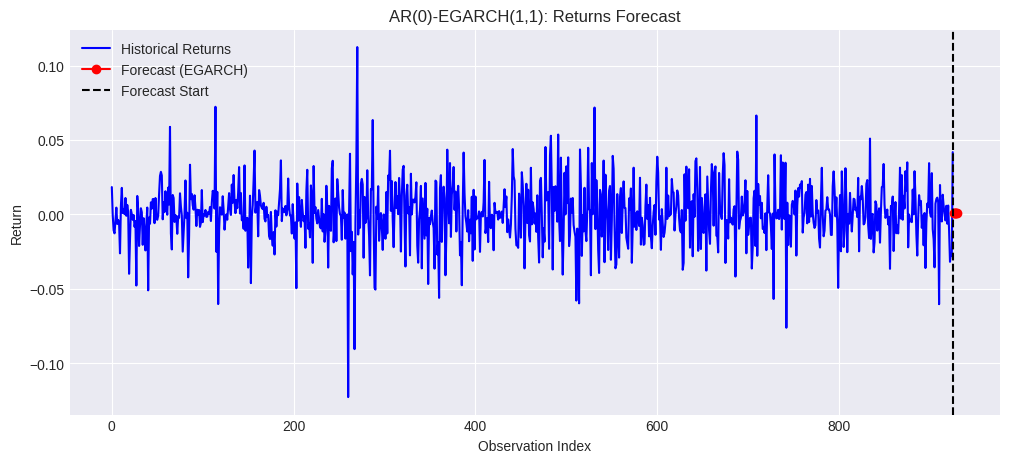

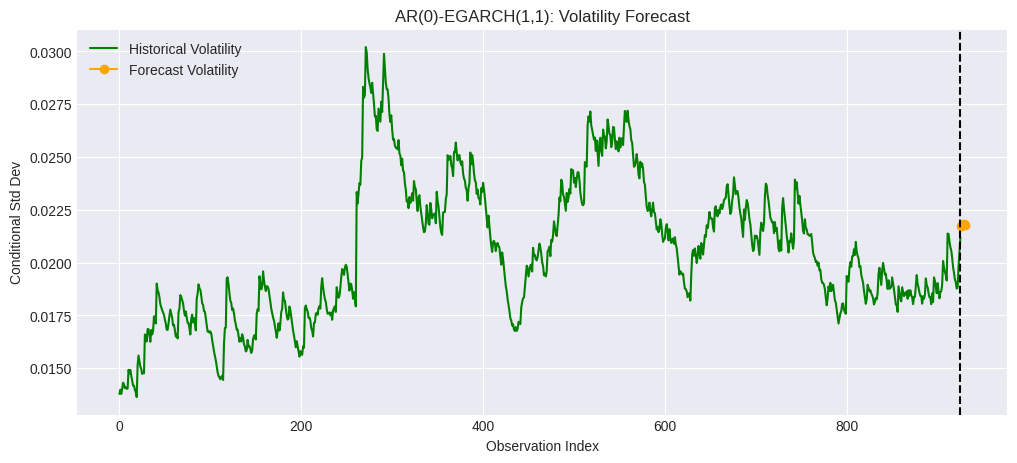

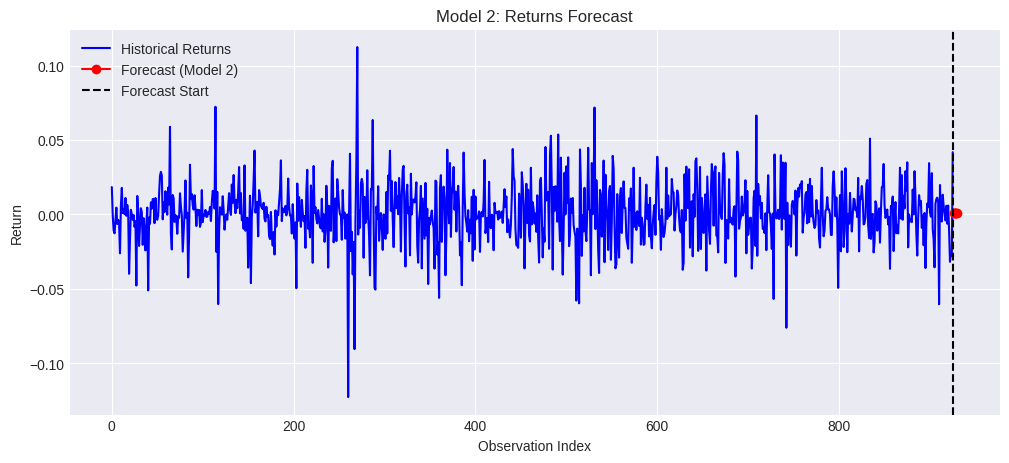

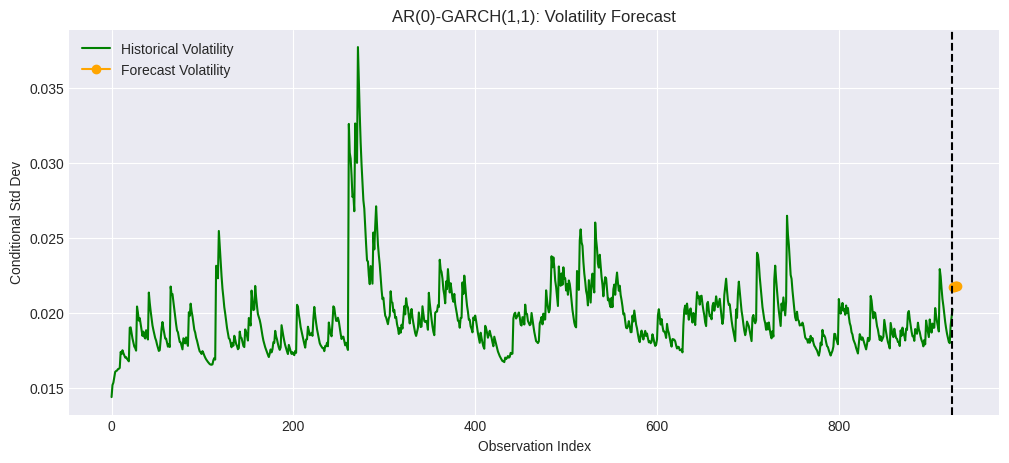

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume log_returns, model1, model2, horizon are already defined.
# Also assume the forecast series have been generated (e.g., mean_forecast1, vol_forecast1, ...)
# but have not yet been assigned an index.

# -------------------------------
# Prepare historical data (keep original index for labeling)
hist_returns = log_returns          # pandas Series with original index
hist_vol1    = model1.conditional_volatility
hist_vol2    = model2.conditional_volatility

# -------------------------------
# Create integer positions for historical data
hist_pos = np.arange(len(hist_returns))          # 0, 1, 2, ..., N-1

# Forecast start position (last historical position)
last_obs_position = len(hist_returns) - 1

# Create integer positions for forecast horizon
forecast_pos = np.arange(last_obs_position + 1, last_obs_position + 1 + horizon)

# Assign these integer positions to the forecast Series
mean_forecast1.index = forecast_pos
vol_forecast1.index  = forecast_pos
mean_forecast2.index = forecast_pos
vol_forecast2.index  = forecast_pos

# -------------------------------
# Optional: generate date labels for the x‑axis if the original index is a DatetimeIndex
use_date_labels = isinstance(hist_returns.index, pd.DatetimeIndex)
if use_date_labels:
    # Get the last date from historical data
    last_date = hist_returns.index[-1]
    # Try to infer frequency for generating future dates (only for labels)
    inferred_freq = pd.infer_freq(hist_returns.index)
    if inferred_freq is None:
        # Fallback: use the median gap between historical dates
        date_diffs = hist_returns.index.to_series().diff().median()
        # Generate future dates by adding multiples of the median gap
        future_dates = [last_date + (i + 1) * date_diffs for i in range(horizon)]
        future_dates = pd.DatetimeIndex(future_dates)
    else:
        # Use the inferred frequency, starting from the next valid period
        # For frequencies like 'B' (business day), using DateOffset is safer
        next_date = last_date + pd.DateOffset(**{inferred_freq: 1})
        future_dates = pd.date_range(start=next_date, periods=horizon, freq=inferred_freq)
    # Combine historical and future dates for tick labeling
    all_dates = hist_returns.index.append(future_dates)
    # We will later select a subset of positions to label
else:
    all_dates = None   # not used

# -------------------------------
# Plot Returns for Model 1
plt.figure(figsize=(12,5))
plt.plot(hist_pos, hist_returns.values, label='Historical Returns', color='blue')
plt.plot(mean_forecast1.index, mean_forecast1.values, label='Forecast (EGARCH)', color='red', marker='o')
plt.axvline(x=last_obs_position, color='black', linestyle='--', label='Forecast Start')
plt.title('AR(0)-EGARCH(1,1): Returns Forecast')
plt.xlabel('Observation Index' if not use_date_labels else 'Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)

# If we have date labels, replace x‑ticks with a selection of dates
if use_date_labels:
    # Choose 6 evenly spaced tick positions across the combined range
    tick_positions = np.linspace(0, len(hist_returns) + horizon - 1, 6, dtype=int)
    tick_labels = [all_dates[i].strftime('%Y-%m-%d') for i in tick_positions]
    plt.xticks(tick_positions, tick_labels, rotation=45)
plt.show()

# Plot Volatility for Model 1
plt.figure(figsize=(12,5))
plt.plot(hist_pos, hist_vol1.values, label='Historical Volatility', color='green')
plt.plot(vol_forecast1.index, vol_forecast1.values, label='Forecast Volatility', color='orange', marker='o')
plt.axvline(x=last_obs_position, color='black', linestyle='--')
plt.title('AR(0)-EGARCH(1,1): Volatility Forecast')
plt.xlabel('Observation Index' if not use_date_labels else 'Date')
plt.ylabel('Conditional Std Dev')
plt.legend()
plt.grid(True)
if use_date_labels:
    plt.xticks(tick_positions, tick_labels, rotation=45)
plt.show()

# Repeat similarly for Model 2 (or combine in subplots)
# For brevity, only Model 2 returns are shown; you can adapt the same pattern.
plt.figure(figsize=(12,5))
plt.plot(hist_pos, hist_returns.values, label='Historical Returns', color='blue')
plt.plot(mean_forecast2.index, mean_forecast2.values, label='Forecast (Model 2)', color='red', marker='o')
plt.axvline(x=last_obs_position, color='black', linestyle='--', label='Forecast Start')
plt.title('Model 2: Returns Forecast')
plt.xlabel('Observation Index' if not use_date_labels else 'Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
if use_date_labels:
    plt.xticks(tick_positions, tick_labels, rotation=45)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(hist_pos, hist_vol2.values, label='Historical Volatility', color='green')
plt.plot(vol_forecast2.index, vol_forecast1.values, label='Forecast Volatility', color='orange', marker='o')
plt.axvline(x=last_obs_position, color='black', linestyle='--')
plt.title('AR(0)-GARCH(1,1): Volatility Forecast')
plt.xlabel('Observation Index' if not use_date_labels else 'Date')
plt.ylabel('Conditional Std Dev')
plt.legend()
plt.grid(True)
if use_date_labels:
    plt.xticks(tick_positions, tick_labels, rotation=45)
plt.show()

**Текст, выделенный полужирным шрифтом**

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss, pacf, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Russtockdaily.csv', parse_dates=True, index_col=0)
price = df['NLMK'].dropna()
log_returns = np.log(price / price.shift(1)).dropna()
print(f"Data range: {log_returns.index[0]} to {log_returns.index[-1]}")
print(f"Number of observations: {len(log_returns)}")

AttributeError: partially initialized module 'pandas' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)

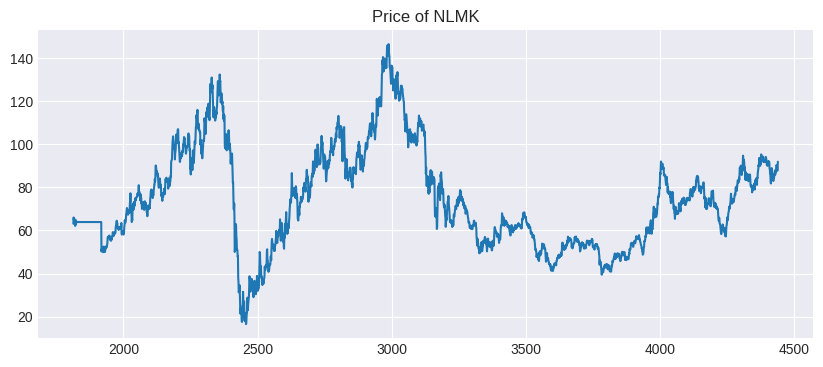

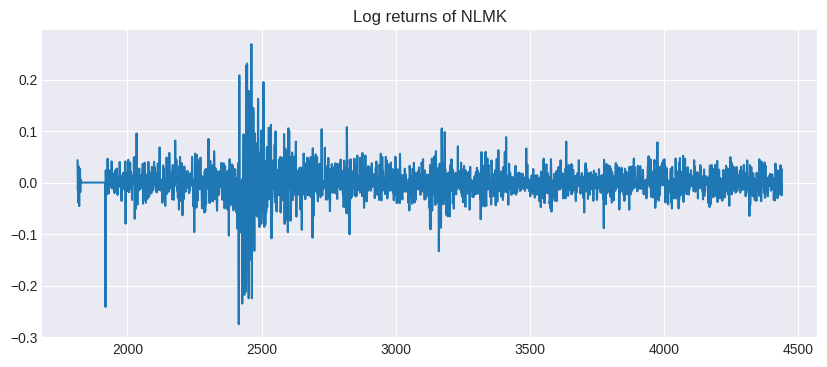

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(price)
plt.title('Price of NLMK')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(log_returns)
plt.title('Log returns of NLMK')
plt.show()

In [ ]:
def run_stationarity_tests(series, name):
    print(f"\n{'='*60}")
    print(f"STATIONARITY ANALYSIS: {name}")
    print(f"{'='*60}")

    # ADF Test with automatic lag selection (AIC)
    print("\n1. AUGMENTED DICKEY-FULLER (ADF) TEST:")
    adf_result = adfuller(series, autolag='AIC')
    print(f"   Test Statistic: {adf_result[0]:.4f}")
    print(f"   p-value: {adf_result[1]:.4f}")
    print(f"   Lags used: {adf_result[2]}")
    print(f"   Critical Values:")
    for key, val in adf_result[4].items():
        print(f"     {key}: {val:.4f}")

    # KPSS Test
    print("\n2. KPSS TEST:")
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f"   Test Statistic: {kpss_result[0]:.4f}")
    print(f"   p-value: {kpss_result[1]:.4f}")

    # PP Test
    print("\n3. PHILLIPS-PERRON (PP) TEST:")
    pp_result = adfuller(series, autolag=None, maxlag=0)
    print(f"   Test Statistic: {pp_result[0]:.4f}")
    print(f"   p-value: {pp_result[1]:.4f}")

    # Determine stationarity
    adf_stationary = adf_result[1] <= 0.05
    kpss_stationary = kpss_result[1] >= 0.05

    print(f"\nCONCLUSION: ", end="")
    if adf_stationary and kpss_stationary:
        print("SERIES IS STATIONARY (both tests agree)")
    elif not adf_stationary and not kpss_stationary:
        print("SERIES IS NON-STATIONARY (both tests agree)")
    else:
        print("MIXED RESULTS - further investigation needed")

    return {
        'adf': adf_result,
        'kpss': kpss_result,
        'pp': pp_result,
        'is_stationary_adf': adf_stationary,
        'is_stationary_kpss': kpss_stationary
    }

run_stationarity_tests(price, 'MOEX price')
run_stationarity_tests(log_returns, 'MOEX returns')


STATIONARITY ANALYSIS: MOEX price

1. AUGMENTED DICKEY-FULLER (ADF) TEST:
   Test Statistic: -2.2783
   p-value: 0.1791
   Lags used: 2
   Critical Values:
     1%: -3.4328
     5%: -2.8626
     10%: -2.5674

2. KPSS TEST:
   Test Statistic: 0.7214
   p-value: 0.0116

3. PHILLIPS-PERRON (PP) TEST:
   Test Statistic: -2.2338
   p-value: 0.1942

CONCLUSION: SERIES IS NON-STATIONARY (both tests agree)

STATIONARITY ANALYSIS: MOEX returns

1. AUGMENTED DICKEY-FULLER (ADF) TEST:
   Test Statistic: -8.6188
   p-value: 0.0000
   Lags used: 25
   Critical Values:
     1%: -3.4329
     5%: -2.8627
     10%: -2.5674

2. KPSS TEST:
   Test Statistic: 0.0486
   p-value: 0.1000

3. PHILLIPS-PERRON (PP) TEST:
   Test Statistic: -47.2450
   p-value: 0.0000

CONCLUSION: SERIES IS STATIONARY (both tests agree)


{'adf': (np.float64(-8.618764487541593),
  np.float64(6.186590054721694e-14),
  25,
  2602,
  {'1%': np.float64(-3.43286566599684),
   '5%': np.float64(-2.862651427026831),
   '10%': np.float64(-2.5673616524036085)},
  np.float64(-10525.53755203378)),
 'kpss': (np.float64(0.04861192334411531),
  np.float64(0.1),
  12,
  {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}),
 'pp': (np.float64(-47.24504437791209),
  0.0,
  0,
  2627,
  {'1%': np.float64(-3.432841702058772),
   '5%': np.float64(-2.8626408441287974),
   '10%': np.float64(-2.5673560179979247)}),
 'is_stationary_adf': np.True_,
 'is_stationary_kpss': np.True_}

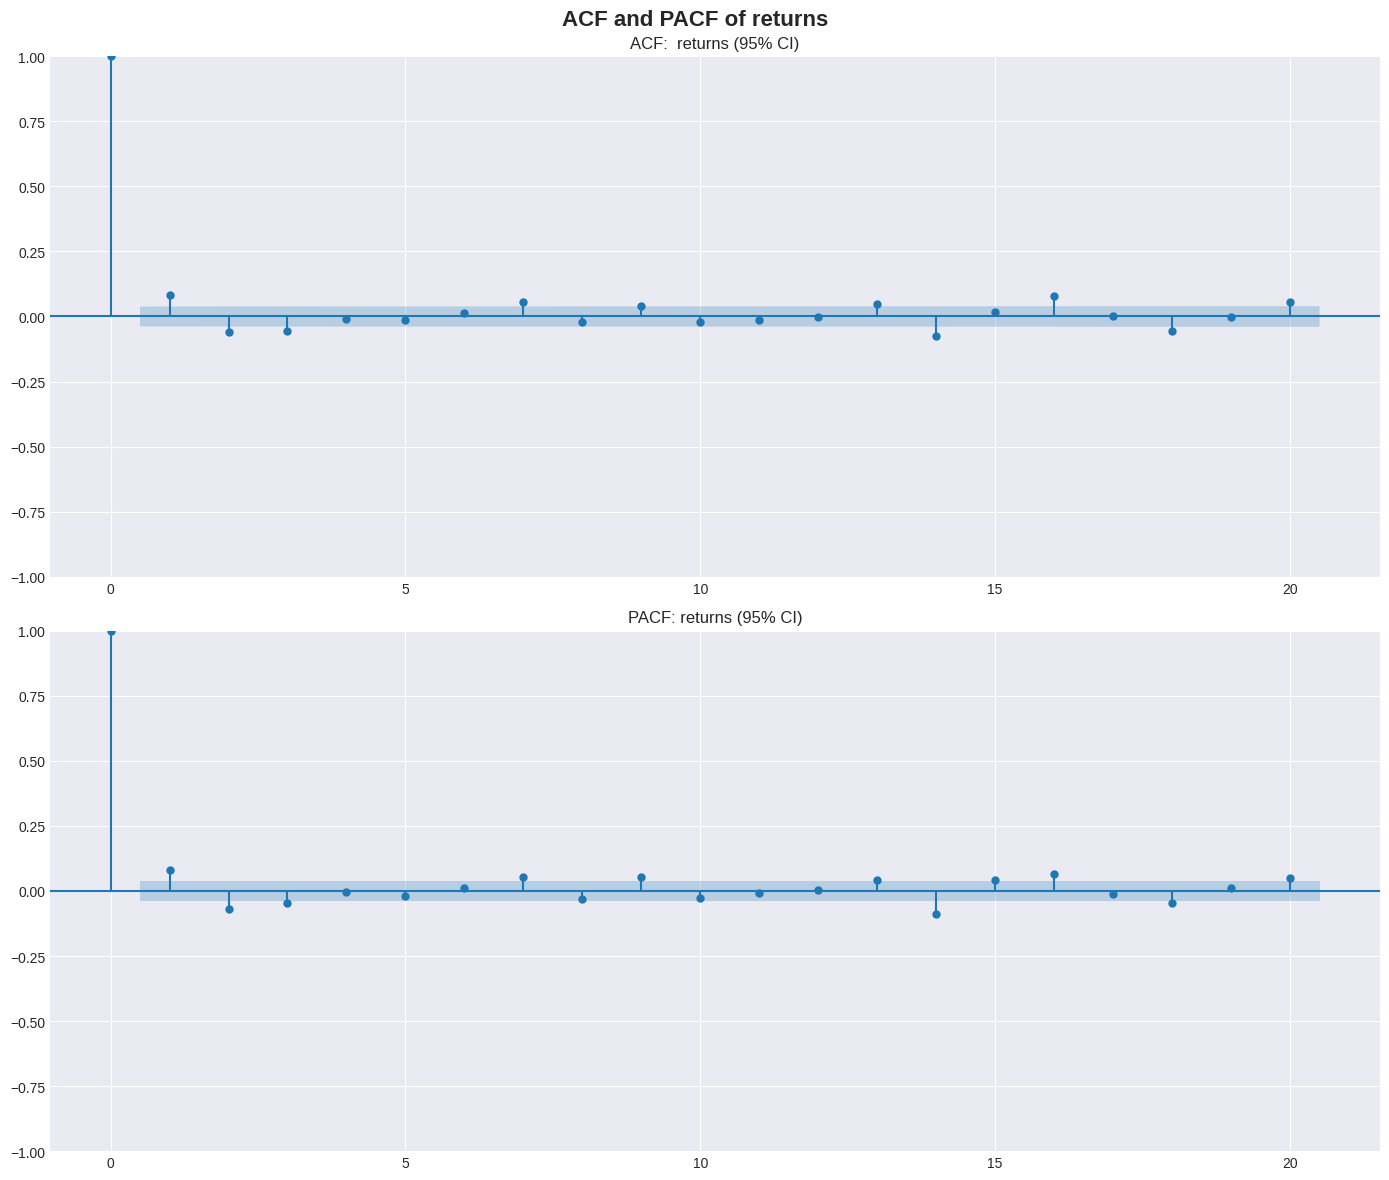

In [ ]:
fig, axes = plt.subplots(2, 1, figsize = (14, 12))
fig.suptitle('ACF and PACF of returns', fontsize=16, fontweight='bold')
plot_acf(log_returns, lags=20, ax=axes[0], alpha=0.05, title=f'ACF:  returns (95% CI)')
plot_pacf(log_returns, lags=20, ax=axes[1], alpha=0.05, title=f'PACF: returns (95% CI)')

plt.tight_layout()
plt.show()

In [ ]:
!pip install armagarch

In [ ]:
!pip install "numpy<2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 13.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9",

In [ ]:
!pip install armagarch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 1.9 MB/s eta 0:00:00


In [ ]:
import armagarch as ag
meanMdl = ag.ARMA(order = {'AR':3,'MA':0})
volMdl = ag.garch(order = {'p':1,'q':1})
distMdl = ag.tStudent()

# create a model
model = ag.empModel(log_returns.to_frame(), meanMdl, volMdl, distMdl)
# fit model
model.fit()

AttributeError: `np.Inf` was removed in the NumPy 2.0 release. Use `np.inf` instead.

In [ ]:

models = {
    # Standard GARCH
    'GARCH(1,1)':       {'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 1},
    'GARCH(2,1)':       {'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 1},
    'GARCH(1,2)':       {'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 2},
    'GARCH(2,2)':       {'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 2},
    'GARCH(1,3)':       {'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 3},
    'GARCH(3,1)':       {'vol': 'GARCH', 'p': 3, 'o': 0, 'q': 1},
    'GARCH(3,3)':       {'vol': 'GARCH', 'p': 3, 'o': 0, 'q': 3},

    # Asymmetric / leverage models
    'EGARCH(1,1)':      {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1},
    'EGARCH(1,2)':      {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 2},
    'EGARCH(2,1)':      {'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 1},
    'GJR-GARCH(1,1)':   {'vol': 'GARCH',   'p': 1, 'o': 1, 'q': 1},   # same as TGARCH
    'GJR-GARCH(2,1)':   {'vol': 'GARCH',   'p': 2, 'o': 1, 'q': 1},
    'GJR-GARCH(1,2)':   {'vol': 'GARCH',   'p': 1, 'o': 1, 'q': 2},

    # Advanced specifications
    'FIGARCH(1,1)':     {'vol': 'FIGARCH', 'p': 1, 'q': 1},            # d is estimated
    'APARCH(1,1)':      {'vol': 'APARCH',  'p': 1, 'o': 1, 'q': 1},    # power estimated
    # Power ARCH (symmetric) – use APARCH with o=0
    'PowerGARCH(1,1)':  {'vol': 'APARCH',  'p': 1, 'o': 0, 'q': 1},
}

# ----------------------------------------------------------------------
# 3. Define AR orders to iterate over
# ----------------------------------------------------------------------
ar_orders = [0, 1, 2, 3]

# ----------------------------------------------------------------------
# 4. Fit each model with AR(0), AR(1), AR(2) mean and collect results
# ----------------------------------------------------------------------
results = []

for name, spec in models.items():
    for ar in ar_orders:
        # Construct model name with AR order
        model_name = f"AR({ar})-{name}"

        # Initialize result dictionary
        res = {
            'Model': model_name,
            'Params': np.nan,
            'AIC': np.nan,
            'BIC': np.nan,
            'LogLik': np.nan,
            'LB_resid_p': np.nan,
            'LB_sq_p': np.nan,
            'Converged': False,
            'Error': ''
        }

        try:
            # Choose mean specification based on AR order
            if ar == 0:
                mean_spec = 'Constant'
                lags = None  # not used for Constant mean
            else:
                mean_spec = 'AR'
                lags = ar

            # Set up the model
            model = arch_model(
                log_returns,
                mean=mean_spec,
                lags=lags,                # only used when mean='AR'
                vol=spec['vol'],
                p=spec['p'],
                o=spec.get('o', 0),       # asymmetry order (default 0 if not given)
                q=spec['q'],
                dist='ged'                 # generalized error distribution
            )

            # Fit the model
            fitted = model.fit(disp='off', show_warning=False)

            # Extract diagnostics
            resid = fitted.resid
            sq_resid = resid**2

            # Ljung-Box test on residuals and squared residuals at lag 10
            lb_resid = acorr_ljungbox(resid, lags=[10], return_df=True).iloc[0, 1]
            lb_sq = acorr_ljungbox(sq_resid, lags=[10], return_df=True).iloc[0, 1]

            # Update result dictionary
            res.update({
                'Params': len(fitted.params),
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'LogLik': fitted.loglikelihood,
                'LB_resid_p': lb_resid,
                'LB_sq_p': lb_sq,
                'Converged': fitted.convergence_flag == 0,
                'Error': '' if fitted.convergence_flag == 0 else f"Convergence flag = {fitted.convergence_flag}"
            })

        except Exception as e:
            # If model fails completely, record the error
            res['Error'] = str(e)[:100]

        results.append(res)

# ----------------------------------------------------------------------
# 5. Create DataFrame and display results
# ----------------------------------------------------------------------
df = pd.DataFrame(results)

# Separate successful (converged and no error) from problematic
df_success = df[df['Converged'] == True].copy()
df_failed  = df[df['Converged'] == False].copy()

# Sort successful models by AIC (lower is better)
df_success = df_success.sort_values('AIC')

# Format numeric columns for readability
for col in ['AIC', 'BIC', 'LogLik']:
    df_success[col] = df_success[col].map('{:.2f}'.format)
df_success['LB_resid_p'] = df_success['LB_resid_p'].map('{:.4f}'.format)
df_success['LB_sq_p']    = df_success['LB_sq_p'].map('{:.4f}'.format)

# Add pass/fail indicators based on p-value > 0.05
df_success['Resid OK']   = df_success['LB_resid_p'].astype(float) > 0.05
df_success['Resid OK']   = df_success['Resid OK'].map({True: '✓', False: '✗'})
df_success['SqResid OK'] = df_success['LB_sq_p'].astype(float) > 0.05
df_success['SqResid OK'] = df_success['SqResid OK'].map({True: '✓', False: '✗'})

# Select columns for final table
display_cols = ['Model', 'Params', 'AIC', 'BIC', 'LogLik',
                'LB_resid_p', 'LB_sq_p', 'Resid OK', 'SqResid OK']

print("\n" + "="*80)
print("GARCH Model Comparison (AR(0), AR(1), AR(2) mean, sorted by AIC)")
print("="*80)
print(df_success[display_cols].to_markdown(index=False, tablefmt="pipe"))

# Show models that did not converge or threw an exception
if not df_failed.empty:
    # Fill any missing error messages
    df_failed['Error'] = df_failed['Error'].fillna("No error message (convergence flag != 0)")
    print("\n" + "-"*80)
    print("Models that did not converge:")
    print(df_failed[['Model', 'Error']].to_markdown(index=False, tablefmt="pipe"))


GARCH Model Comparison (AR(0), AR(1), AR(2) mean, sorted by AIC)
| Model                 |   Params |              AIC |              BIC |          LogLik |   LB_resid_p |   LB_sq_p | Resid OK   | SqResid OK   |
|:----------------------|---------:|-----------------:|-----------------:|----------------:|-------------:|----------:|:-----------|:-------------|
| AR(1)-EGARCH(2,1)     |        8 | -12075.2         | -12028.2         |   6045.61       |          nan |       nan | ✗          | ✗            |
| AR(3)-EGARCH(1,1)     |        9 | -12065.1         | -12012.3         |   6041.57       |          nan |       nan | ✗          | ✗            |
| AR(0)-PowerGARCH(1,1) |        6 | -12000.2         | -11964.9         |   6006.08       |            0 |         0 | ✗          | ✗            |
| AR(0)-GJR-GARCH(2,1)  |        7 | -11993.9         | -11952.8         |   6003.96       |            0 |         0 | ✗          | ✗            |
| AR(1)-GJR-GARCH(1,2)  |        8 | -11981.3 

In [ ]:
# Example with one of your selected models
# Re-fit AR(0)-EGARCH(1,1)
model1 = arch_model(log_returns, mean='Constant', vol='APARCH', p=1, o=1, q=1, dist='t').fit(disp='off')
# Re-fit AR(0)-GARCH(1,1)
model2 = arch_model(log_returns, mean='AR', lags=2, vol='EGARCH', p=1, o=0, q=1, dist='t').fit(disp='off')

horizon = 5

# For EGARCH (and any model), use simulation method
forecasts1 = model1.forecast(horizon=horizon, method='simulation')
mean_forecast1 = forecasts1.mean.iloc[-1]          # point forecasts of returns
vol_forecast1  = np.sqrt(forecasts1.variance.iloc[-1])  # average simulated variance → std dev

# For GARCH, analytic works, but we can also use simulation (optional)
forecasts2 = model2.forecast(horizon=horizon, method='simulation')
mean_forecast2 = forecasts2.mean.iloc[-1]
vol_forecast2  = np.sqrt(forecasts2.variance.iloc[-1])

print("Model 1 (POWER GARCH) point forecasts (returns):")
print(mean_forecast1)
print("\nModel 1 volatility forecasts (std dev):")
print(vol_forecast1)

print("\nModel 2 (EGARCH) point forecasts (returns):")
print(mean_forecast2)
print("\nModel 2 volatility forecasts (std dev):")
print(vol_forecast2)

Model 1 (POWER GARCH) point forecasts (returns):
h.1    32.381731
h.2    32.381731
h.3    32.381731
h.4    32.381731
h.5    32.381731
Name: 4441, dtype: float64

Model 1 volatility forecasts (std dev):
h.1    8.290915
h.2    3.836119
h.3    1.775562
h.4    0.834948
h.5    0.401120
Name: 4441, dtype: float64

Model 2 (EGARCH) point forecasts (returns):
h.1    3.700276e+01
h.2   -3.078099e+03
h.3    2.531929e+05
h.4   -2.081748e+07
h.5    1.711594e+09
Name: 4441, dtype: float64

Model 2 volatility forecasts (std dev):
h.1    inf
h.2    inf
h.3    inf
h.4    inf
h.5    inf
Name: 4441, dtype: float64


/tmp/ipython-input-3710077668.py:5: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  model2 = arch_model(log_returns, mean='AR', lags=2, vol='EGARCH', p=1, o=0, q=1, dist='t').fit(disp='off')


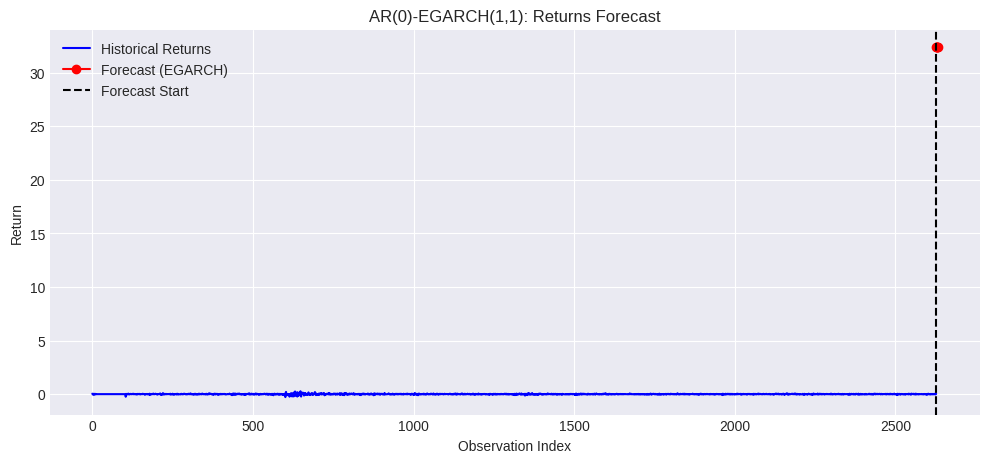

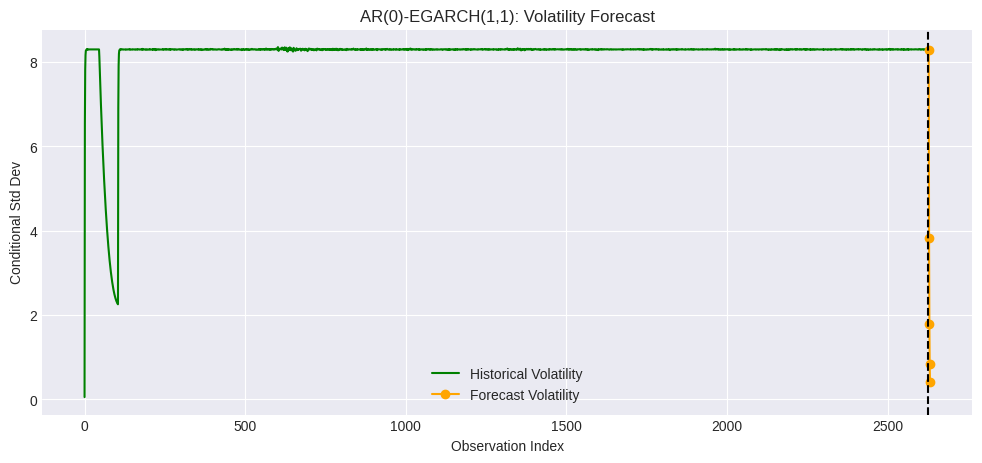

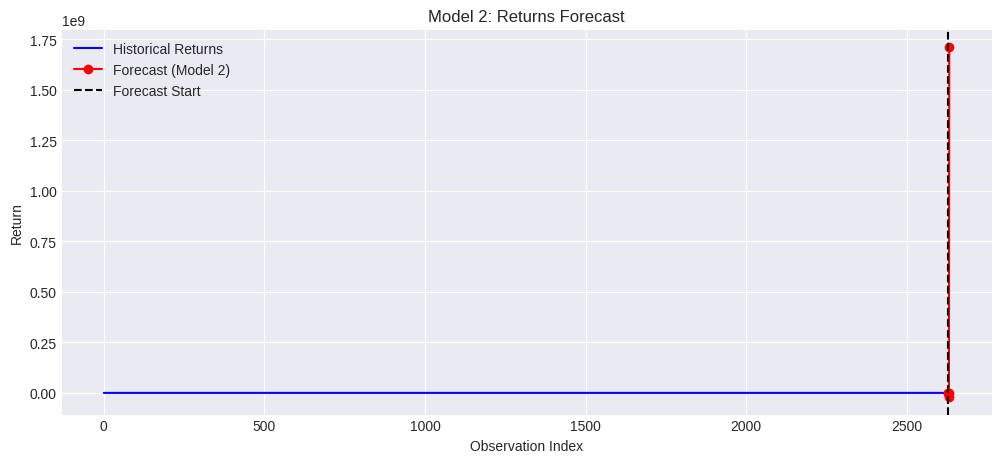

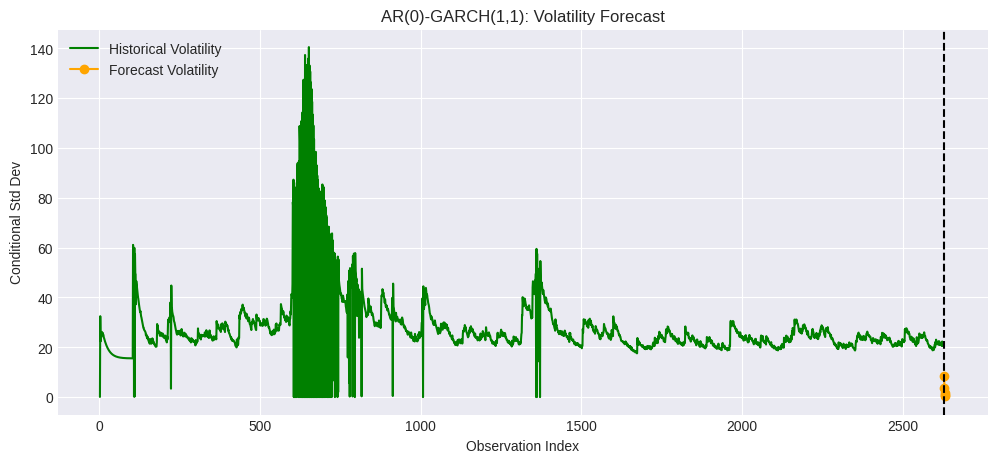

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume log_returns, model1, model2, horizon are already defined.
# Also assume the forecast series have been generated (e.g., mean_forecast1, vol_forecast1, ...)
# but have not yet been assigned an index.

# -------------------------------
# Prepare historical data (keep original index for labeling)
hist_returns = log_returns          # pandas Series with original index
hist_vol1    = model1.conditional_volatility
hist_vol2    = model2.conditional_volatility

# -------------------------------
# Create integer positions for historical data
hist_pos = np.arange(len(hist_returns))          # 0, 1, 2, ..., N-1

# Forecast start position (last historical position)
last_obs_position = len(hist_returns) - 1

# Create integer positions for forecast horizon
forecast_pos = np.arange(last_obs_position + 1, last_obs_position + 1 + horizon)

# Assign these integer positions to the forecast Series
mean_forecast1.index = forecast_pos
vol_forecast1.index  = forecast_pos
mean_forecast2.index = forecast_pos
vol_forecast2.index  = forecast_pos

# -------------------------------
# Optional: generate date labels for the x‑axis if the original index is a DatetimeIndex
use_date_labels = isinstance(hist_returns.index, pd.DatetimeIndex)
if use_date_labels:
    # Get the last date from historical data
    last_date = hist_returns.index[-1]
    # Try to infer frequency for generating future dates (only for labels)
    inferred_freq = pd.infer_freq(hist_returns.index)
    if inferred_freq is None:
        # Fallback: use the median gap between historical dates
        date_diffs = hist_returns.index.to_series().diff().median()
        # Generate future dates by adding multiples of the median gap
        future_dates = [last_date + (i + 1) * date_diffs for i in range(horizon)]
        future_dates = pd.DatetimeIndex(future_dates)
    else:
        # Use the inferred frequency, starting from the next valid period
        # For frequencies like 'B' (business day), using DateOffset is safer
        next_date = last_date + pd.DateOffset(**{inferred_freq: 1})
        future_dates = pd.date_range(start=next_date, periods=horizon, freq=inferred_freq)
    # Combine historical and future dates for tick labeling
    all_dates = hist_returns.index.append(future_dates)
    # We will later select a subset of positions to label
else:
    all_dates = None   # not used

# -------------------------------
# Plot Returns for Model 1
plt.figure(figsize=(12,5))
plt.plot(hist_pos, hist_returns.values, label='Historical Returns', color='blue')
plt.plot(mean_forecast1.index, mean_forecast1.values, label='Forecast (EGARCH)', color='red', marker='o')
plt.axvline(x=last_obs_position, color='black', linestyle='--', label='Forecast Start')
plt.title('AR(0)-EGARCH(1,1): Returns Forecast')
plt.xlabel('Observation Index' if not use_date_labels else 'Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)

# If we have date labels, replace x‑ticks with a selection of dates
if use_date_labels:
    # Choose 6 evenly spaced tick positions across the combined range
    tick_positions = np.linspace(0, len(hist_returns) + horizon - 1, 6, dtype=int)
    tick_labels = [all_dates[i].strftime('%Y-%m-%d') for i in tick_positions]
    plt.xticks(tick_positions, tick_labels, rotation=45)
plt.show()

# Plot Volatility for Model 1
plt.figure(figsize=(12,5))
plt.plot(hist_pos, hist_vol1.values, label='Historical Volatility', color='green')
plt.plot(vol_forecast1.index, vol_forecast1.values, label='Forecast Volatility', color='orange', marker='o')
plt.axvline(x=last_obs_position, color='black', linestyle='--')
plt.title('AR(0)-EGARCH(1,1): Volatility Forecast')
plt.xlabel('Observation Index' if not use_date_labels else 'Date')
plt.ylabel('Conditional Std Dev')
plt.legend()
plt.grid(True)
if use_date_labels:
    plt.xticks(tick_positions, tick_labels, rotation=45)
plt.show()

# Repeat similarly for Model 2 (or combine in subplots)
# For brevity, only Model 2 returns are shown; you can adapt the same pattern.
plt.figure(figsize=(12,5))
plt.plot(hist_pos, hist_returns.values, label='Historical Returns', color='blue')
plt.plot(mean_forecast2.index, mean_forecast2.values, label='Forecast (Model 2)', color='red', marker='o')
plt.axvline(x=last_obs_position, color='black', linestyle='--', label='Forecast Start')
plt.title('Model 2: Returns Forecast')
plt.xlabel('Observation Index' if not use_date_labels else 'Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
if use_date_labels:
    plt.xticks(tick_positions, tick_labels, rotation=45)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(hist_pos, hist_vol2.values, label='Historical Volatility', color='green')
plt.plot(vol_forecast2.index, vol_forecast1.values, label='Forecast Volatility', color='orange', marker='o')
plt.axvline(x=last_obs_position, color='black', linestyle='--')
plt.title('AR(0)-GARCH(1,1): Volatility Forecast')
plt.xlabel('Observation Index' if not use_date_labels else 'Date')
plt.ylabel('Conditional Std Dev')
plt.legend()
plt.grid(True)
if use_date_labels:
    plt.xticks(tick_positions, tick_labels, rotation=45)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
model

In [ ]:
!pip install arch

In [ ]:
"""
ARCH(4) model simulation and estimation for two sample sizes.
True model: ε_t = σ_t * z_t, z_t ~ N(0,1)
σ_t^2 = 1 + 0.3 ε_{t-1}^2 + 0.25 ε_{t-2}^2 + 0.15 ε_{t-3}^2 + 0.1 ε_{t-4}^2
Unconditional variance = 1 / (1 - 0.8) = 5
Mean = 0, skewness = 0
"""

import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import skew

# Use a modern style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

# True parameters
omega_true = 1.0
alphas_true = [0.3, 0.25, 0.15, 0.1]
sum_alpha_true = sum(alphas_true)
uncond_var_true = omega_true / (1 - sum_alpha_true)  # 5.0
mean_true = 0.0
skew_true = 0.0

def generate_arch4(n, omega, alphas, burn=1000):
    """Generate ARCH(4) series with burn-in."""
    p = len(alphas)
    total = n + burn
    eps = np.zeros(total)
    sigma2 = np.zeros(total)
    z = np.random.normal(size=total)
    for t in range(p, total):
        sigma2[t] = omega + np.sum(alphas * eps[t-p:t][::-1]**2)
        eps[t] = np.sqrt(sigma2[t]) * z[t]
    return eps[-n:], sigma2[-n:]

# Only keep the two largest sample sizes
lengths = [10000, 1000]
results_arch = {}

# Create figure: 2 rows (one per sample size), 2 columns (series and variance)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ARCH(4) Simulated Series and Conditional Variance', fontsize=16, y=1.02)

# Colors for better distinction
true_color = '#1f77b4'      # blue
est_color = '#ff7f0e'        # orange

for idx, N in enumerate(lengths):
    np.random.seed(123 + idx)  # different seed for each length
    eps, sigma2_true = generate_arch4(N, omega_true, alphas_true)

    # Fit ARCH(4) with zero mean
    model = arch_model(eps, mean='zero', vol='ARCH', p=4)
    res = model.fit(disp='off')

    # Print full summary
    print(f"\n{'='*60}")
    print(f"ARCH(4) Estimation Results for N = {N}")
    print(f"{'='*60}")
    print(res.summary().as_text())
    print()

    # Extract estimates and standard errors
    omega_est = res.params['omega']
    omega_se = res.std_err['omega']
    alpha_ests = [res.params[f'alpha[{i}]'] for i in range(1,5)]
    alpha_ses = [res.std_err[f'alpha[{i}]'] for i in range(1,5)]
    sum_alpha_est = sum(alpha_ests)
    # Unconditional variance estimate (if sum(alpha) < 1)
    if sum_alpha_est < 1:
        uncond_var_est = omega_est / (1 - sum_alpha_est)
    else:
        uncond_var_est = np.nan

    # Sample moments
    sample_mean = np.mean(eps)
    sample_var = np.var(eps)
    sample_skew = skew(eps)

    # Store results
    results_arch[N] = {
        'omega_est': omega_est, 'omega_se': omega_se,
        'alpha_ests': alpha_ests, 'alpha_ses': alpha_ses,
        'sum_alpha_est': sum_alpha_est,
        'uncond_var_est': uncond_var_est,
        'sample_mean': sample_mean,
        'sample_var': sample_var,
        'sample_skew': sample_skew,
        'res': res,
        'sigma2_true': sigma2_true,
        'eps': eps
    }

    # Plot in the corresponding row
    ax_left = axes[idx, 0]
    ax_right = axes[idx, 1]

    # Left: time series
    ax_left.plot(eps, lw=0.8, color=true_color, alpha=0.7)
    ax_left.set_title(f'ARCH(4) Series (N={N})', fontsize=12)
    ax_left.set_xlabel('Time')
    ax_left.set_ylabel('ε_t')
    ax_left.grid(True, alpha=0.3)

    # Right: conditional variance
    cond_vol_est = res.conditional_volatility
    ax_right.plot(sigma2_true, label='True σ²', lw=1.5, color=true_color, linestyle='--')
    ax_right.plot(cond_vol_est**2, label='Estimated σ²', lw=1.2, color=est_color, alpha=0.8)
    ax_right.set_title(f'Conditional Variance (N={N})', fontsize=12)
    ax_right.set_xlabel('Time')
    ax_right.set_ylabel('Variance')
    ax_right.legend()
    ax_right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison table for the two sample sizes
print("\n" + "="*80)
print("ARCH(4) Estimation Results Comparison Across Sample Sizes")
print("="*80)
header = f"{'Parameter':<15} {'True':<10} " + " ".join([f"N={N:<10}" for N in lengths])
print(header)
print("-"*80)

# omega
row = f"{'omega':<15} {omega_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['omega_est']:.3f} ({r['omega_se']:.3f})  "
print(row)

# alphas
for i in range(4):
    row = f"alpha[{i+1}]   {alphas_true[i]:<10.3f} "
    for N in lengths:
        r = results_arch[N]
        row += f"{r['alpha_ests'][i]:.3f} ({r['alpha_ses'][i]:.3f})  "
    print(row)

# sum of alphas
row = f"{'sum(alpha)':<15} {sum_alpha_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['sum_alpha_est']:.3f} (---)  "
print(row)

# unconditional variance
row = f"{'uncond var':<15} {uncond_var_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    val = r['uncond_var_est']
    row += f"{val:.3f} (---)  " if not np.isnan(val) else " nan (---)  "
print(row)

# sample mean
row = f"{'sample mean':<15} {mean_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['sample_mean']:.3f} (---)  "
print(row)

# sample variance
row = f"{'sample var':<15} {uncond_var_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['sample_var']:.3f} (---)  "
print(row)

# sample skew
row = f"{'sample skew':<15} {skew_true:<10.3f} "
for N in lengths:
    r = results_arch[N]
    row += f"{r['sample_skew']:.3f} (---)  "
print(row)


GARCH(1,1) Estimation Results for N = 10000
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13702.4
Distribution:                  Normal   AIC:                           27410.9
Method:            Maximum Likelihood   BIC:                           27432.5
                                        No. Observations:                10000
Date:                Wed, Feb 18 2026   Df Residuals:                    10000
Time:                        22:37:28   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.11

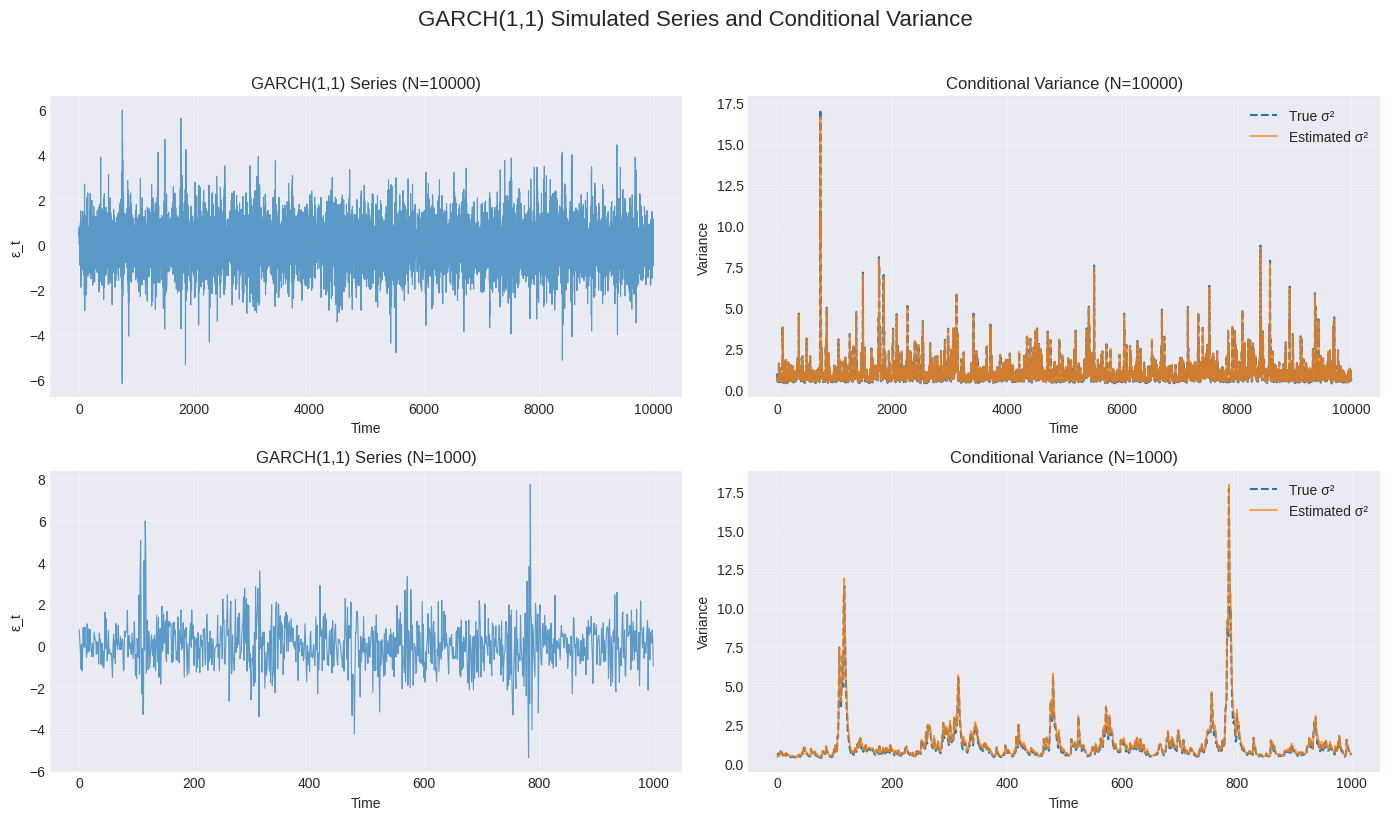


GARCH(1,1) Estimation Results Comparison Across Sample Sizes
Parameter       True       N=10000      N=1000      
--------------------------------------------------------------------------------
omega           0.100      0.114 (0.010)  0.092 (0.025)  
alpha           0.200      0.197 (0.011)  0.194 (0.030)  
beta            0.700      0.694 (0.017)  0.735 (0.035)  
persistence     0.900      0.891 (---)  0.929 (---)  
uncond var      1.000      1.045 (---)  1.296 (---)  
sample mean     0.000      -0.007 (---)  0.020 (---)  
sample var      1.000      1.042 (---)  1.328 (---)  
sample skew     0.000      0.020 (---)  0.383 (---)  


In [ ]:
"""
GARCH(1,1) model simulation and estimation for two sample sizes.
True model: ε_t = σ_t * z_t, z_t ~ N(0,1)
σ_t^2 = 0.1 + 0.2 ε_{t-1}^2 + 0.7 σ_{t-1}^2
Unconditional variance = 0.1 / (1 - 0.9) = 1
Mean = 0, skewness = 0
"""

import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import skew

# Use a modern style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

# True parameters
omega_true = 0.1
alpha_true = 0.2
beta_true = 0.7
persistence = alpha_true + beta_true   # 0.9
uncond_var_true = omega_true / (1 - persistence)  # 1.0
mean_true = 0.0
skew_true = 0.0

def generate_garch11(n, omega, alpha, beta, burn=1000):
    """Generate GARCH(1,1) series with burn-in."""
    total = n + burn
    eps = np.zeros(total)
    sigma2 = np.zeros(total)
    z = np.random.normal(size=total)
    # Initialize at unconditional variance
    sigma2[0] = omega / (1 - alpha - beta)
    eps[0] = np.sqrt(sigma2[0]) * z[0]
    for t in range(1, total):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        eps[t] = np.sqrt(sigma2[t]) * z[t]
    return eps[-n:], sigma2[-n:]

# Only keep the two largest sample sizes
lengths = [10000, 1000]
results_garch = {}

# Create figure: 2 rows (one per sample size), 2 columns (series and variance)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('GARCH(1,1) Simulated Series and Conditional Variance', fontsize=16, y=1.02)

# Colors for better distinction
true_color = '#1f77b4'      # blue
est_color = '#ff7f0e'        # orange

for idx, N in enumerate(lengths):
    np.random.seed(456 + idx)  # different seed for each length
    eps, sigma2_true = generate_garch11(N, omega_true, alpha_true, beta_true)

    # Fit GARCH(1,1) with zero mean
    model = arch_model(eps, mean='zero', vol='GARCH', p=1, q=1)
    res = model.fit(disp='off')

    # Print full summary
    print(f"\n{'='*60}")
    print(f"GARCH(1,1) Estimation Results for N = {N}")
    print(f"{'='*60}")
    print(res.summary().as_text())
    print()

    # Extract estimates and standard errors
    omega_est = res.params['omega']
    omega_se = res.std_err['omega']
    alpha_est = res.params['alpha[1]']
    alpha_se = res.std_err['alpha[1]']
    beta_est = res.params['beta[1]']
    beta_se = res.std_err['beta[1]']
    persist_est = alpha_est + beta_est
    # Unconditional variance estimate (if persist < 1)
    if persist_est < 1:
        uncond_var_est = omega_est / (1 - persist_est)
    else:
        uncond_var_est = np.nan

    # Sample moments
    sample_mean = np.mean(eps)
    sample_var = np.var(eps)
    sample_skew = skew(eps)

    # Store results
    results_garch[N] = {
        'omega_est': omega_est, 'omega_se': omega_se,
        'alpha_est': alpha_est, 'alpha_se': alpha_se,
        'beta_est': beta_est, 'beta_se': beta_se,
        'persist_est': persist_est,
        'uncond_var_est': uncond_var_est,
        'sample_mean': sample_mean,
        'sample_var': sample_var,
        'sample_skew': sample_skew,
        'res': res,
        'sigma2_true': sigma2_true,
        'eps': eps
    }

    # Plot in the corresponding row
    ax_left = axes[idx, 0]
    ax_right = axes[idx, 1]

    # Left: time series
    ax_left.plot(eps, lw=0.8, color=true_color, alpha=0.7)
    ax_left.set_title(f'GARCH(1,1) Series (N={N})', fontsize=12)
    ax_left.set_xlabel('Time')
    ax_left.set_ylabel('ε_t')
    ax_left.grid(True, alpha=0.3)

    # Right: conditional variance
    cond_vol_est = res.conditional_volatility
    ax_right.plot(sigma2_true, label='True σ²', lw=1.5, color=true_color, linestyle='--')
    ax_right.plot(cond_vol_est**2, label='Estimated σ²', lw=1.2, color=est_color, alpha=0.8)
    ax_right.set_title(f'Conditional Variance (N={N})', fontsize=12)
    ax_right.set_xlabel('Time')
    ax_right.set_ylabel('Variance')
    ax_right.legend()
    ax_right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison table for the two sample sizes
print("\n" + "="*80)
print("GARCH(1,1) Estimation Results Comparison Across Sample Sizes")
print("="*80)
header = f"{'Parameter':<15} {'True':<10} " + " ".join([f"N={N:<10}" for N in lengths])
print(header)
print("-"*80)

# omega
row = f"{'omega':<15} {omega_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['omega_est']:.3f} ({r['omega_se']:.3f})  "
print(row)

# alpha
row = f"{'alpha':<15} {alpha_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['alpha_est']:.3f} ({r['alpha_se']:.3f})  "
print(row)

# beta
row = f"{'beta':<15} {beta_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['beta_est']:.3f} ({r['beta_se']:.3f})  "
print(row)

# persistence
row = f"{'persistence':<15} {persistence:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['persist_est']:.3f} (---)  "
print(row)

# unconditional variance
row = f"{'uncond var':<15} {uncond_var_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    val = r['uncond_var_est']
    row += f"{val:.3f} (---)  " if not np.isnan(val) else " nan (---)  "
print(row)

# sample mean
row = f"{'sample mean':<15} {mean_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['sample_mean']:.3f} (---)  "
print(row)

# sample variance
row = f"{'sample var':<15} {uncond_var_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['sample_var']:.3f} (---)  "
print(row)

# sample skew
row = f"{'sample skew':<15} {skew_true:<10.3f} "
for N in lengths:
    r = results_garch[N]
    row += f"{r['sample_skew']:.3f} (---)  "
print(row)

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf
from statsmodels.tools.sm_exceptions import ValueWarning
import warnings

def eacf(x, ar_order_max=7, ma_order_max=7, print_table=True, alpha=0.05):
    """
    Compute the Extended Autocorrelation Function (EACF) for a time series.

    Parameters
    ----------
    x : array_like
        The input time series (assumed stationary).
    ar_order_max : int, optional
        Maximum autoregressive order to consider (rows). Default is 7.
    ma_order_max : int, optional
        Maximum moving average order to consider (columns). Default is 7.
    print_table : bool, optional
        If True, print a formatted EACF table with significance indicators.
        Default is True.
    alpha : float, optional
        Significance level for the autocorrelation bounds (two-tailed).
        The critical value is approximately `2/sqrt(n)` for alpha=0.05.
        Default is 0.05.

    Returns
    -------
    eacf_matrix : pandas.DataFrame
        A DataFrame with rows corresponding to AR order p (0..ar_order_max)
        and columns corresponding to MA order q (1..ma_order_max). Each entry
        is the sample autocorrelation of the residuals from an AR(p) fit at lag q.
        If `print_table` is True, the matrix is printed with symbols:
            '+' if autocorrelation > critical value,
            '-' if autocorrelation < -critical value,
            '.' otherwise.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        raise ValueError("Time series must have at least 2 observations.")

    # Critical value for autocorrelation significance (approximate)
    crit_val = 2 / np.sqrt(n)  # ~1.96/sqrt(n) for 5% two-tailed

    # Prepare result matrix: rows = AR order, cols = MA lag (starting at lag 1)
    eacf_table = np.zeros((ar_order_max + 1, ma_order_max))

    # Compute residuals for each AR order
    for p in range(ar_order_max + 1):
        if p == 0:
            # For AR(0), residuals are the demeaned series (to remove mean)
            resid = x - np.mean(x)
        else:
            # Fit AR(p) model with constant (intercept)
            try:
                with warnings.catch_warnings():
                    # Suppress warnings about small sample sizes (optional)
                    warnings.simplefilter("ignore", ValueWarning)
                    model = AutoReg(x, lags=p, trend='c').fit()
                resid = model.resid
            except Exception as e:
                # If model fails to fit, fill row with NaN
                eacf_table[p, :] = np.nan
                continue

        # Compute autocorrelations of residuals up to lag ma_order_max
        # We exclude lag 0 (always 1) and take lags 1..ma_order_max
        resid_acf = acf(resid, nlags=ma_order_max, fft=False)[1:ma_order_max+1]
        eacf_table[p, :] = resid_acf

    # Create DataFrame for nice output
    columns = [f"MA {q}" for q in range(1, ma_order_max + 1)]
    index = [f"AR {p}" for p in range(ar_order_max + 1)]
    eacf_df = pd.DataFrame(eacf_table, index=index, columns=columns)

    if print_table:
        print("EACF table (significance indicators: + > crit, - < -crit, . otherwise)")
        print(f"Critical value: ±{crit_val:.3f} (alpha={alpha})\n")

        # Build a symbol matrix
        symbol_matrix = []
        for i, row in eacf_df.iterrows():
            sym_row = []
            for val in row:
                if np.isnan(val):
                    sym_row.append("?")
                elif val > crit_val:
                    sym_row.append("+")
                elif val < -crit_val:
                    sym_row.append("-")
                else:
                    sym_row.append(".")
            symbol_matrix.append(sym_row)

        # Print header
        header = "     " + " ".join(f"{q:3}" for q in range(1, ma_order_max+1))
        print(header)
        print("    " + "-" * (3 * ma_order_max))

        # Print each row with AR order label
        for p, sym_row in enumerate(symbol_matrix):
            print(f"{p:2} | " + " ".join(f"{sym:3}" for sym in sym_row))
        print()

    return eacf_df

# Example usage (if run as script)
if __name__ == "__main__":
    # Generate an ARMA(1,1) process for demonstration
    np.random.seed(123)
    from statsmodels.tsa.arima_process import ArmaProcess
    ar = np.array([1, -0.7])
    ma = np.array([1, 0.4])
    arma_process = ArmaProcess(ar, ma)
    y = arma_process.generate_sample(nsample=100)

    # Compute EACF
    eacf_matrix = eacf(y, ar_order_max=5, ma_order_max=5, print_table=True)

EACF table (significance indicators: + > crit, - < -crit, . otherwise)
Critical value: ±0.200 (alpha=0.05)

       1   2   3   4   5
    ---------------
 0 | +   +   +   +   +  
 1 | +   .   .   .   .  
 2 | .   .   .   .   .  
 3 | .   .   .   .   .  
 4 | .   .   .   .   .  
 5 | .   .   .   .   .  

